# Earnings Return Prediction Challenge - Making Features

In the template, you will find expressions for all 87 features.

## Standard imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Notebook configuration
- Please set the **<span style="color:red">config['enddate']</span>** to the most recent Friday. Do not change any other config parameters. 

- The environment might take around one minute to load
- The  **Operators** are functions that can be used to apply a series of transformations to a data variable or alpha.
> [Introduction to Operators](https://trexsim.com/trexsim/pysim/tutorial2022/operators.html)
> 
> Find all available  operators in the [operators list](https://www.trexsim.com/trexsim/pysim/comptutorial/operators.html)

In [2]:
import operators as op              # find all available operators, https://www.trexsim.com/trexsim/pysim/comptutorial/operators.html
import utilities as utils
import strategy_utilities as sutil
from strategy_research import load_env

config = {
    'enddate': 20240830,            # Please setting the config['enddate'] to the most recent Friday.
    'region': 'USA',
    'universe': 'top3000',
    'delay': 0,
    'booksize':1e6,
    'refit_interval': 'OneQuarter',
    'filter_function_uuid': 'none',
    'fit_function_uuid': 'none',
    'pp_function_uuid': 'none',
    'tf_function_uuid': 'none',
    'postalpha': False,
    'compress': False,    
    'load_cache': False,
    'save_cache': False,
    'skip_post_strategy': True,
    'skip_test_cases': True,
    'strat_dir': './'
}

def tf_function(preA, data): return preA
function_dict = {'tf_function': tf_function}

env = load_env('USA')
data = sutil.create_strategy_data(function_dict, config, 'full', env, use_pre_compressed=True)
data = sutil.add_builtin_functions(data, function_dict, config, env)

is container True
Variable numdates is loaded from /home/newprod/production/data/USA/simvars/numdates/numdates.20240830.raw.mat
Variable numstocks is loaded from /home/newprod/production/data/USA/simvars/numstocks/numstocks.20240830.raw.mat
Variable dates is loaded from /home/newprod/production/data/USA/simvars/dates/dates.20240830.adj_amend.mat 4697
Variable numdates is loaded from /home/newprod/production/data/USA/simvars/numdates/numdates.20240830.adj_amend.mat 4697
Variable startdate is loaded from /home/newprod/production/data/USA/simvars/startdate/startdate.20240830.adj_amend.mat 4697
Variable enddate is loaded from /home/newprod/production/data/USA/simvars/enddate/enddate.20240830.adj_amend.mat 4697
Variable spread_timeweighted_allday is loaded from /home/newprod/production/data/USA/simvars/spread_timeweighted_allday/spread_timeweighted_allday.20240830.adj_amend.ci 4697
Variable numstocks is loaded from /home/newprod/production/data/USA/simvars/numstocks/numstocks.20240830.adj_a

## **Mask**

Most data variables at Trexquant are 2D matrices with dimensions _num\_stocks_ x _num\_dates_. We want to filter on the dates when earnings were announced and convert the 2D matrix to a vector so that it can be used in an ML model.

To find the earnings date we use the data variable [trading_days_til_next_ann](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/trading_days_til_next_ann/). We also require the time of announcement which we get from the data variable [fs_next_ann_time](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/fs_next_ann_time/). We use the following logic to construct the mask:
1. If the annoucement time is before the trading time (1500), set the earnings return day as today.
2. If the annoucement time is after the trading time (1500), set the earnings return day as the next day.

The code in the cell below constructs the mask

In [3]:
### ---- ---- ---- ---- No need to modify the code below ---- ---- ---- ---- ###

# contruct earning mask based on trading_days_til_next_ann
valid_mask = (data['load_simvar_hhmm']('trading_days_til_next_ann') == 1)
fs_next_ann_time = data['load_simvar_hhmm']('fs_next_ann_time')

# based on trading_days_til_next_ann and fs_next_ann_time
# delay one day if earnings is announced after we trade
valid_effect_mask = np.zeros_like(valid_mask, dtype=np.float32)
for si, di in zip(*np.where((valid_mask == 1) & (data['valids']))):

    # skip if we are unable to get the target
    if di + data['delay'] >= data['numdates']:
        continue

    time = fs_next_ann_time[si, di]

    if time <= 1500:
        target_di = di
    elif time > 1500 and di + 1 < data['numdates']:
        target_di = di+1
    if valid_effect_mask[si, target_di] != 1:
        valid_effect_mask[si, target_di] = 1
        
bet_days_mask = valid_effect_mask==1
bet_days_mask = op.at_nan2zero(bet_days_mask*1.0)
flatten_mask = (bet_days_mask==1.0)

## **Target**

For this challenge we will use one-day forward ret1_excess as the target
- target columns: `target`, which is the forward [ret1_excess](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/ret1_excess/)
- dates: `dates` column is the masked dates, which is the day we want to enter our position before the earning announcement.
- stock index: `si`
- date index: `di`
- `[si,di]` data point indicates that we want to enter into the position for the stock at si th index and di th date just before the company announces its results

In [4]:
### ---- ---- ---- ---- No need to modify the code below ---- ---- ---- ---- ###

ret1_excess = data['load_simvar_hhmm']('ret1_excess')
ret1_excess[ret1_excess>0.25] = 0.25
ret1_excess[ret1_excess<-0.25] = -0.25

fwd_ret = op.ts_delay((ret1_excess),-1) # one day forward ret1_excess

# modify mask to remove points where target is invalid
flatten_mask[np.isnan(fwd_ret)] = False  
target = fwd_ret[flatten_mask]

# put target into the dataframe
df = pd.DataFrame()
df['target'] = target

num_of_stocks, num_of_dates = ret1_excess.shape
si_list = np.array([list(np.arange(num_of_stocks))]*num_of_dates).transpose()
di_list = np.array([list(np.arange(num_of_dates))]*num_of_stocks)

df['si'] = si_list[flatten_mask]
df['di'] = di_list[flatten_mask]
dates_mat = np.tile(data['dates'], (num_of_stocks,1))
df['dates'] = dates_mat[flatten_mask]


import numpy as np
from sklearn.preprocessing import MinMaxScaler

def cs_MinMaxScaler(alpha_matrix, min=-5.0, max=5.0):
    numstocks, numdates = alpha_matrix.shape
    scaler = MinMaxScaler(feature_range=(min, max))
    scaled_matrix = np.zeros_like(alpha_matrix)
    for i in range(numdates):
        column = alpha_matrix[:, i].reshape(-1, 1)
        scaled_matrix[:, i] = scaler.fit_transform(column).flatten()
    return scaled_matrix

def normalize_features(alpha):
    MIN,MAX = -4.0, 4.0
    alpha = op.cs_winsor(alpha, 0.001, remove_extreme=False)
    alpha = cs_MinMaxScaler(alpha, min=MIN, max=MAX)
    return alpha

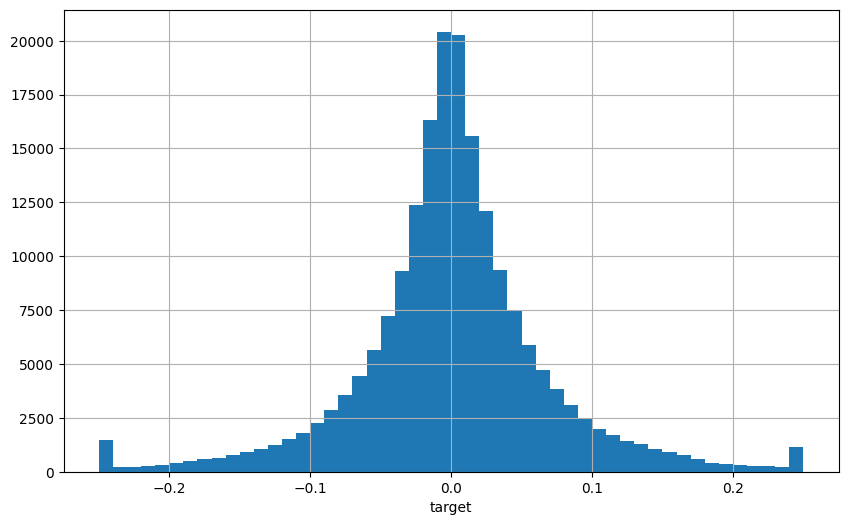

In [5]:
%matplotlib inline

import matplotlib.pyplot as plt
%matplotlib inline
def hist_show(df, fname):
    df[fname].hist(bins=50,figsize=(10, 6))
    plt.xlabel(fname)
    plt.show()    
hist_show(df, 'target')

## **Features**

For this challenge you can use any of the data variables available in the [data description](https://trexsim.com/trexsim/pysim/data_description/USA/).
You may further apply any transformations to the data variables that you deem appropriate.

Please keep in mind that **all features used must be dimensionless**. Features that have dimensions of price of number of shares are subject to adjustment which introduces a forward bias. An easy way to check if a data variable is subject to adjustment is to check if there is anything in the `adjfactor_type` column in the data description.
Features which are subject to adjustment can be normalized using operators like `ts_zscore`, `ts_norm` and `ts_std_normalized`. Find all available operators in [operators list](https://www.trexsim.com/trexsim/pysim/comptutorial/operators.html).

You can combine existing features and apply operators to make new features as long as the transformations are reasonable.

## **ALL Features**

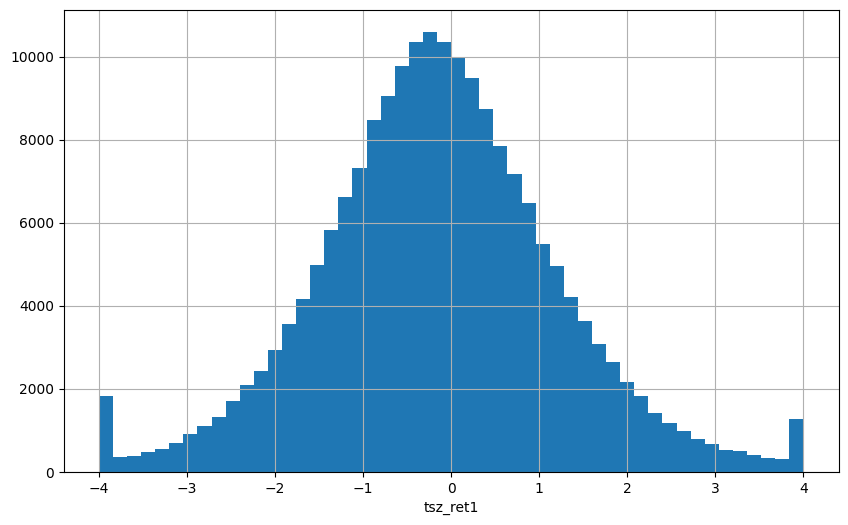

In [6]:
####### feature 1: tsz_ret1
ret1 = data['load_simvar_hhmm']('ret1')
tsz_ret1 = op.at_nan2zero(op.ts_zscore(ret1, 21))

tsz_ret1 = normalize_features(tsz_ret1)
df['tsz_ret1'] = tsz_ret1[flatten_mask]

#
hist_show(df, 'tsz_ret1')

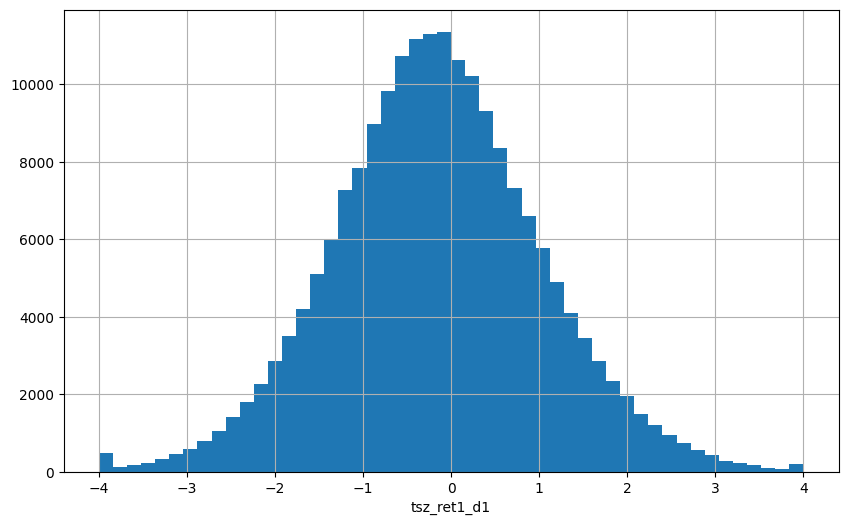

In [7]:
####### feature 2: tsz_ret1_delay1
tsz_ret1_d1 = op.at_nan2zero(op.ts_zscore(op.ts_delay(ret1,1), 21))    
tsz_ret1_d1 = normalize_features(tsz_ret1_d1)

df['tsz_ret1_d1'] = tsz_ret1_d1[flatten_mask] 

hist_show(df, 'tsz_ret1_d1')

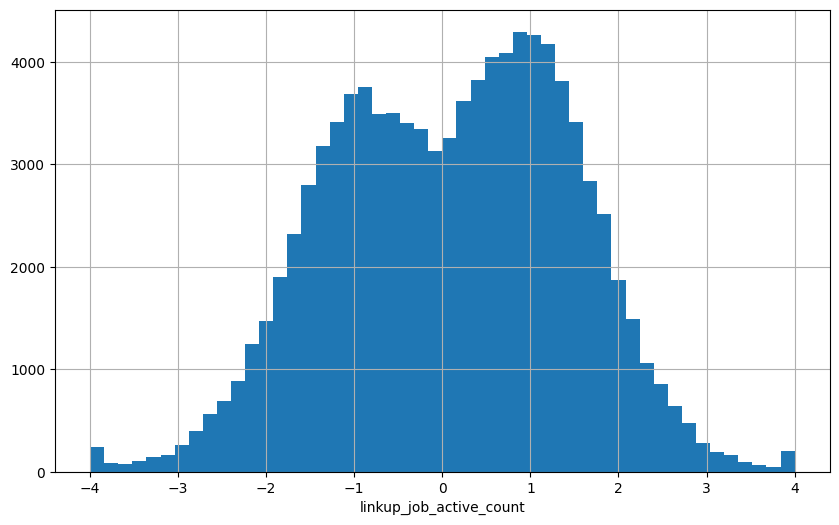

In [8]:
####### feature 3: modified linkup_job_active_count
linkup_job_active_count = op.at_zero2nan(data['load_simvar_hhmm']('linkup_job_active_count'))
linkup_job_active_count = op.at_nan2zero(op.ts_zscore(op.ts_fill(linkup_job_active_count), 21))
linkup_job_active_count = op.at_zero2nan(linkup_job_active_count)
linkup_job_active_count = normalize_features(linkup_job_active_count)

df['linkup_job_active_count'] = linkup_job_active_count[flatten_mask]

hist_show(df, 'linkup_job_active_count')

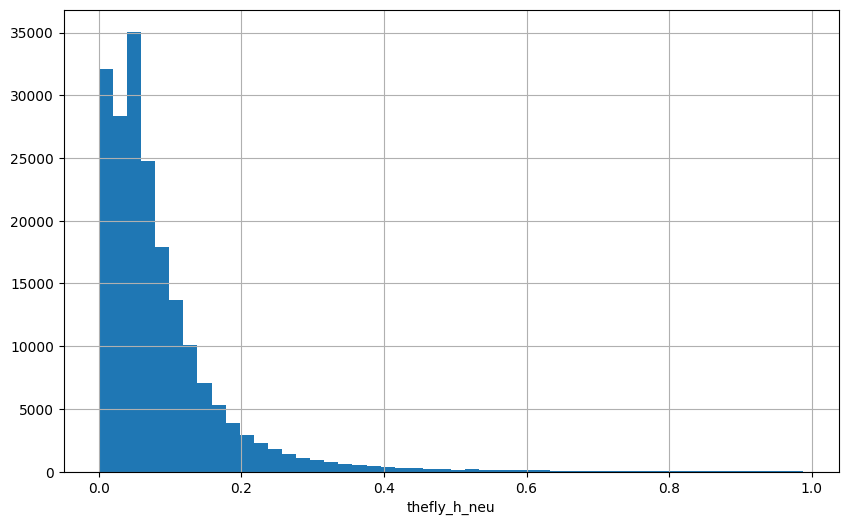

In [9]:
####### feature 4: sentiment feature:
neu = op.ts_fill(data['load_simvar_hhmm']('thefly_h_neu'))
neu = op.at_nan2zero(op.ts_mean(neu, 63))

# neu = normalize_features(neu)

df['thefly_h_neu'] = neu[flatten_mask]
hist_show(df, 'thefly_h_neu')

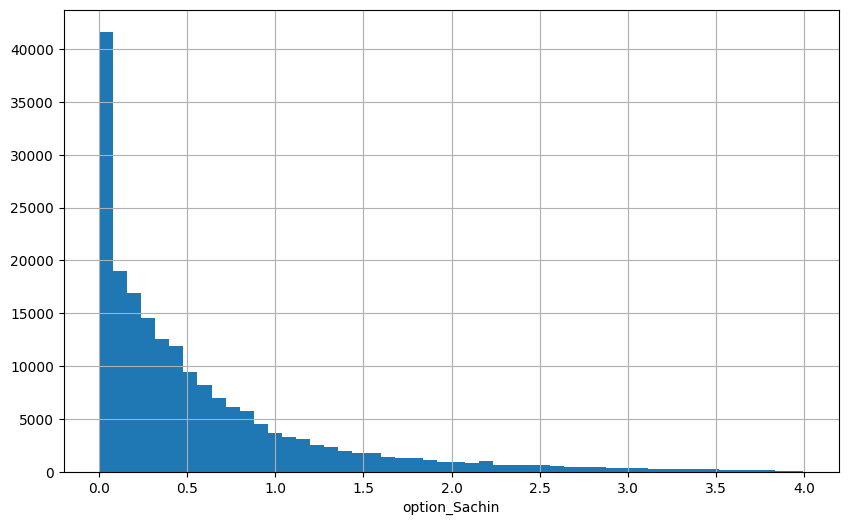

In [10]:
####### feature 5: options feature: OTM Volume Ratio
num_days_30 = 10
call_itm_vol_30 = op.ts_fill(data['load_simvar_hhmm']('ivy_ITM_call_30_volume_vol_wt_mean'))
call_atm_vol_30 = op.ts_fill(data['load_simvar_hhmm']('ivy_ATM_call_30_volume_vol_wt_mean'))
call_otm_vol_30 = op.ts_fill(data['load_simvar_hhmm']('ivy_OTM_call_30_volume_vol_wt_mean'))

# var_load = op.ts_mean(call_otm_vol_30,num_days_30)/(op.ts_mean(call_itm_vol_30,num_days_30) + op.ts_mean(call_atm_vol_30,num_days_30))

num = op.ts_mean(call_otm_vol_30,num_days_30)
den = (op.ts_mean(call_itm_vol_30,num_days_30) + op.ts_mean(call_atm_vol_30,num_days_30))

var_load = num/((0.25*num) + den)
var_load = op.at_nan2zero(var_load)

# var_load = normalize_features(var_load)
df['option_Sachin'] = var_load[flatten_mask]

hist_show(df, 'option_Sachin')

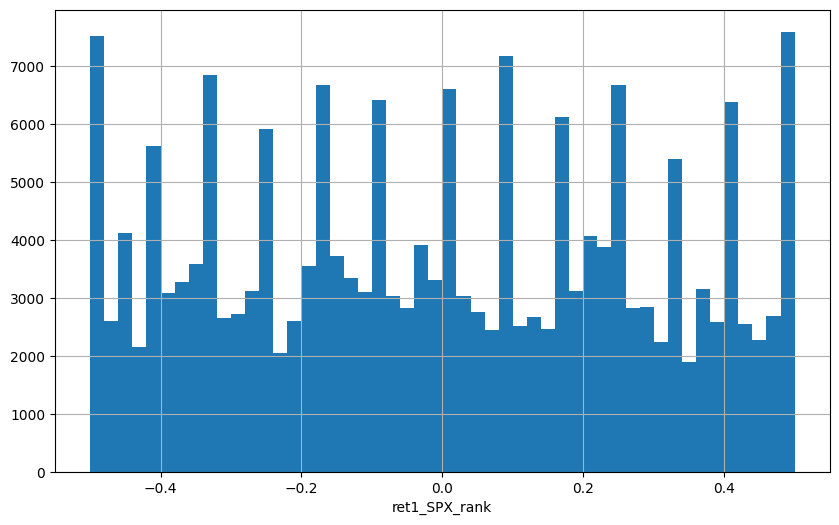

In [11]:
####### feature 6: 1-d feature, ret1_spx
var_load = op.ts_fill(data['load_simvar_hhmm']('ret1_SPX'))
var_load = op.at_nan2zero(op.ts_rank(var_load,63)) - (1.5)

# var_load = normalize_features(var_load)

df['ret1_SPX_rank'] = var_load[flatten_mask]

hist_show(df, 'ret1_SPX_rank')

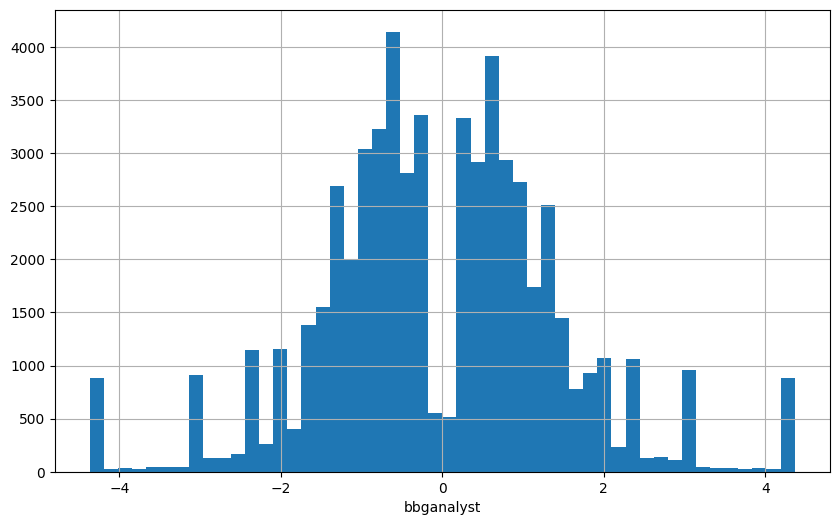

In [12]:
####### feature 7: analyst feature
var_name = 'bbganalyst'
var = op.ts_fill(data['load_simvar_hhmm'](var_name))
var = op.ts_zscore(var,21)
var = op.at_zero2nan(var)

# var = normalize_features(var)

# df[var_name] = op.at_nan2zero(var[flatten_mask])
df[var_name] = (var[flatten_mask])

hist_show(df, 'bbganalyst')

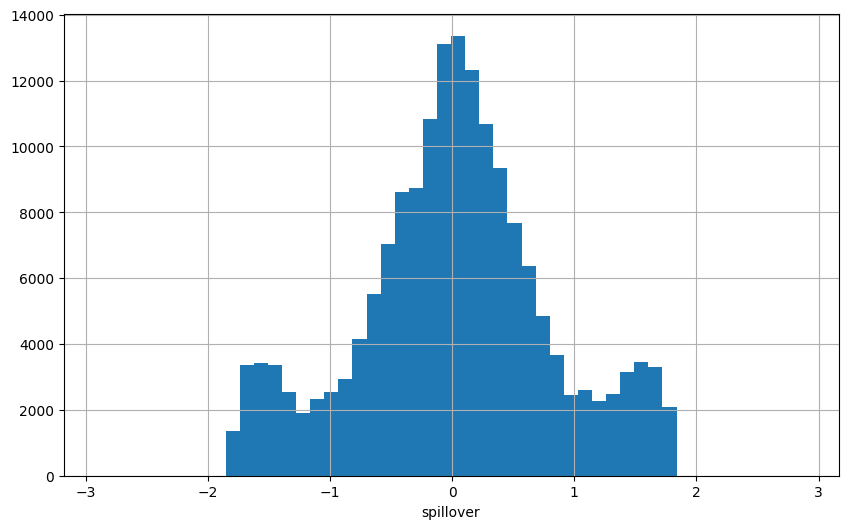

In [13]:
####### feature 8: spillover
var_industry = data['load_simvar_hhmm']('industry')
def fill_nans_by_industry_average(array, industry):
    unique_industries = np.unique(industry)
    filled_array = np.copy(array)

    for industry_value in unique_industries:
        industry_mask = (industry == industry_value)
        for col in range(array.shape[1]):
            column_values = array[:, col]
            industry_column_values = column_values[industry_mask[:, col]]
            mean_value = np.nanmean(industry_column_values)
            filled_array[industry_mask[:, col], col] = np.where(np.isnan(filled_array[industry_mask[:, col], col]), mean_value, filled_array[industry_mask[:, col], col])

    return filled_array
    
v_ret1 = data['load_simvar']('ret1')
v_ret1 = np.where(abs(op.ts_zscore(v_ret1,5))>1.0, op.ts_zscore(v_ret1,5), np.nan)
v_ret1 = v_ret1 * (op.ts_delay(1.0*flatten_mask,1))
v_ret1 = op.ts_sum((v_ret1),5)
# Apply the function
filled_array = fill_nans_by_industry_average(op.at_zero2nan(v_ret1), var_industry)
avg_ret1_recent = filled_array


# filled_array = normalize_features(filled_array)
df['spillover'] = filled_array[flatten_mask]

hist_show(df, 'spillover')

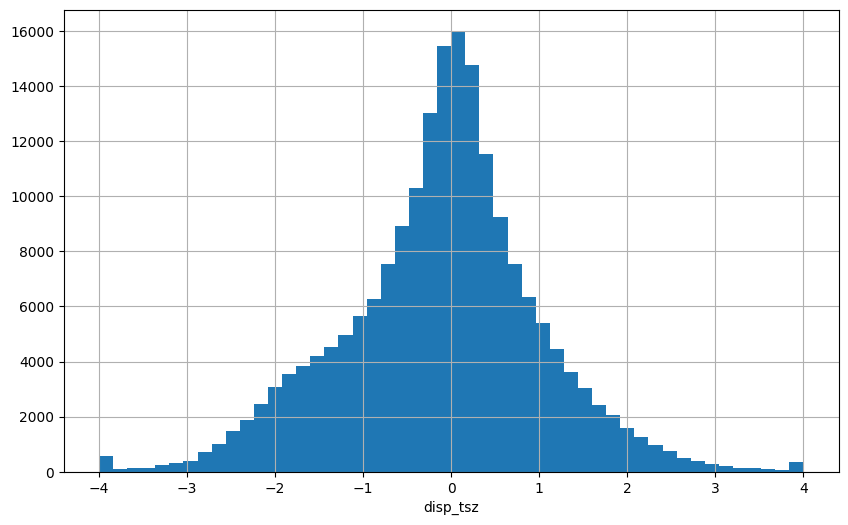

In [14]:
####### feature 9: disp_tsz | standard deviation of analyst earnings estimates
disp = data["load_simvar_hhmm"]('markit_FC_CVFY1EPS')
disp_fill_tsz = op.at_nan2zero(op.ts_zscore(op.ts_fill(disp),63))

disp_fill_tsz = normalize_features(disp_fill_tsz)
df["disp_tsz"] = disp_fill_tsz[flatten_mask]
hist_show(df, 'disp_tsz')

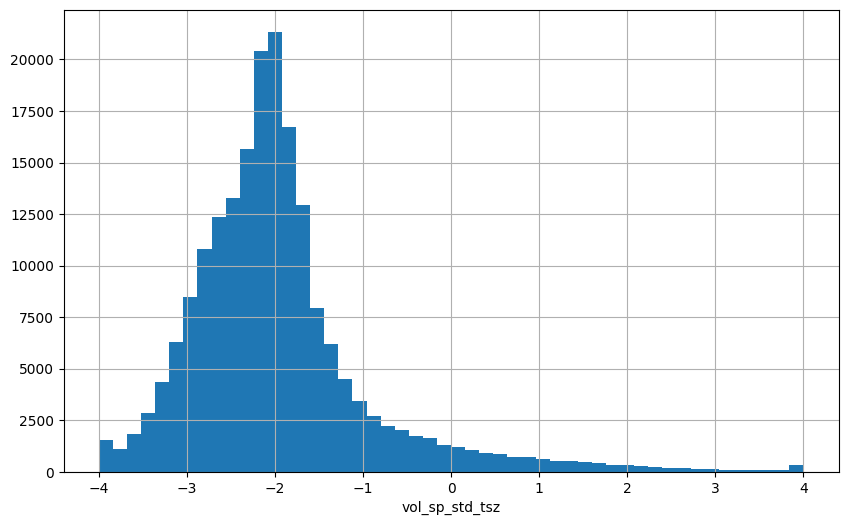

In [15]:
####### feature 10: vol_sp_std_tsz
vol_sp = data["load_simvar_hhmm"]('ivy_risk_premium_30')
vol_sp_pp = np.clip(vol_sp, -2.5, 2.5)
vol_sp_std = op.at_nan2zero(op.ts_zscore(op.ts_std(vol_sp_pp, 5), 63))

vol_sp_std = normalize_features(vol_sp_std)

df["vol_sp_std_tsz"] = vol_sp_std[flatten_mask]
hist_show(df, 'vol_sp_std_tsz')

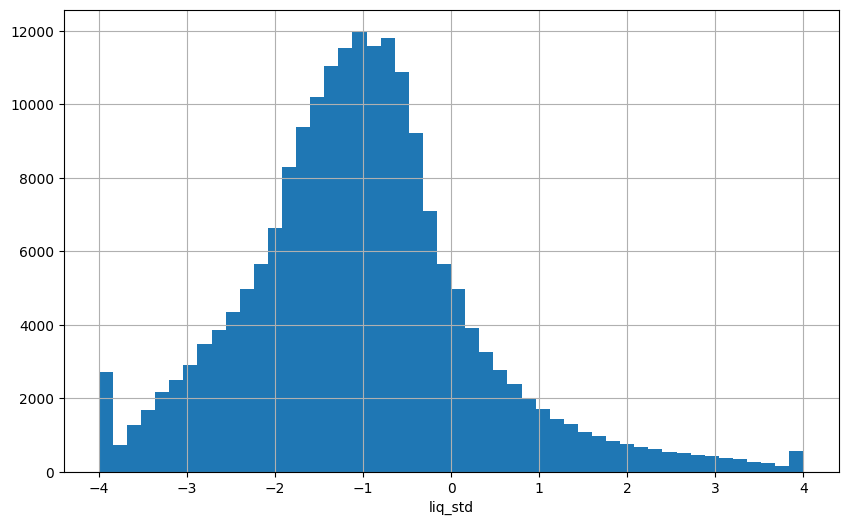

In [16]:
####### feature 11: liq_std
markit_Milliq = data['load_simvar_hhmm']('markit_Milliq')
markit_Milliq_std_5_csz_tsz = op.at_nan2zero(op.cs_zscore(op.ts_zscore(op.ts_std(markit_Milliq, 5), 63))) # 0.100, 0.094 (w 63)

markit_Milliq_std_5_csz_tsz = normalize_features(markit_Milliq_std_5_csz_tsz)

df['liq_std'] = markit_Milliq_std_5_csz_tsz[flatten_mask]
hist_show(df, 'liq_std')

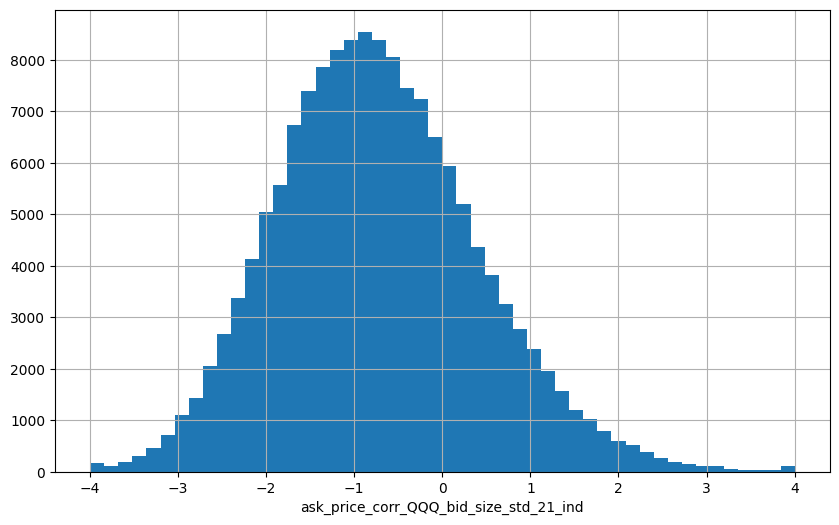

In [17]:
####### feature 12: ask_price_corr_QQQ_bid_size_std_21_ind
intra_disp = data['load_simvar_hhmm']("ask_price_corr_QQQ_bid_size")
industry = data['load_simvar_hhmm']("industry")
ask_price_corr_QQQ_bid_size_std_21_ind = op.at_nan2zero(op.cs_indneut(op.cs_zscore((-op.ts_std(intra_disp, 21))), industry))

ask_price_corr_QQQ_bid_size_std_21_ind = op.at_zero2nan(ask_price_corr_QQQ_bid_size_std_21_ind)
ask_price_corr_QQQ_bid_size_std_21_ind = normalize_features(ask_price_corr_QQQ_bid_size_std_21_ind)

df['ask_price_corr_QQQ_bid_size_std_21_ind'] = ask_price_corr_QQQ_bid_size_std_21_ind[flatten_mask]
hist_show(df, 'ask_price_corr_QQQ_bid_size_std_21_ind')

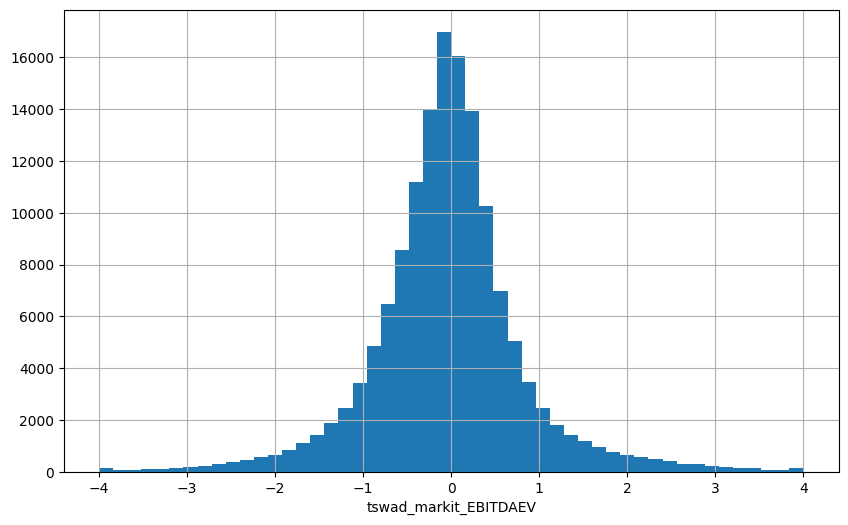

In [18]:
###### feature 13: tswad_markit_EBITDAEV
def ts_wtd_avg_diff(time_series, n, delay, mode, base = 2):
    wtd_avg_var = np.zeros_like(time_series)
    wts = np.zeros(n)
    if (mode == 'linear'):
        wts = np.linspace(2/(n+1), 2/(n*(n+1)), n)
    elif (mode == 'quadratic'):
        wts = np.linspace(1, n, n)
        wts = 1 / wts**2
    elif (mode == 'exponential'):
        wts = base ** -np.arange(1.0, n+1.0)
    elif (mode == 'equal'):
        wts = np.ones(n)
    else:
        raise Exception("Please input equal, linear, quadratic or exponential mode")
    wts = wts/np.sum(wts)
    for i in range(1, n+1):
        wtd_avg_var += wts[i-1]*op.ts_delay(time_series, delay*i)
    return var - wtd_avg_var 

varname = 'markit_EBITDAEV'
var = data['load_simvar_hhmm'](varname)
tswad_var =  op.at_nan2zero(ts_wtd_avg_diff(op.ts_fill(var), 5, 63, 'equal'))
tswad_var = op.at_zero2nan(tswad_var)

tswad_var = normalize_features(tswad_var)

df['tswad_'+varname] = tswad_var[flatten_mask]
hist_show(df, 'tswad_'+varname)

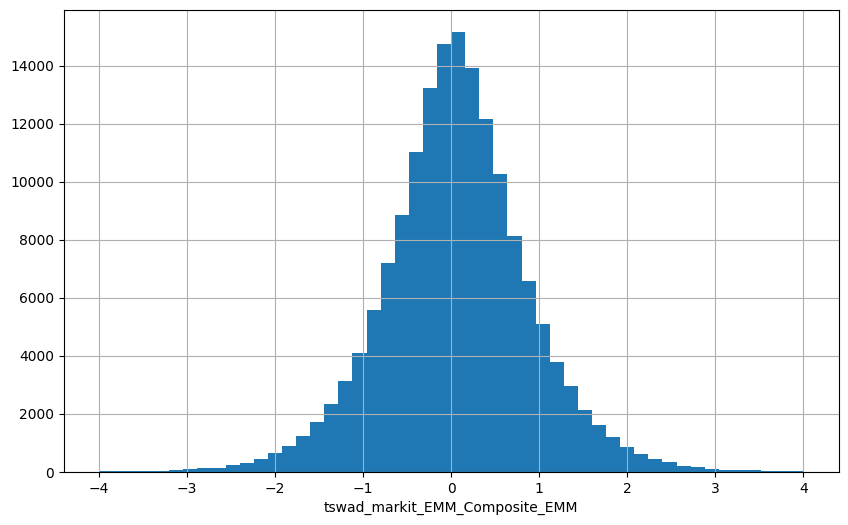

In [19]:
###### feature 14: tswad_markit_EMM_Composite_EMM
varname = 'markit_EMM_Composite_EMM'
var = data['load_simvar_hhmm'](varname)
tswad_var =  op.at_nan2zero(ts_wtd_avg_diff(op.ts_fill(var), 7, 21, 'exponential'))
tswad_var = op.at_zero2nan(tswad_var)

tswad_var = normalize_features(tswad_var)

df['tswad_'+varname] = tswad_var[flatten_mask]

hist_show(df, 'tswad_'+varname)

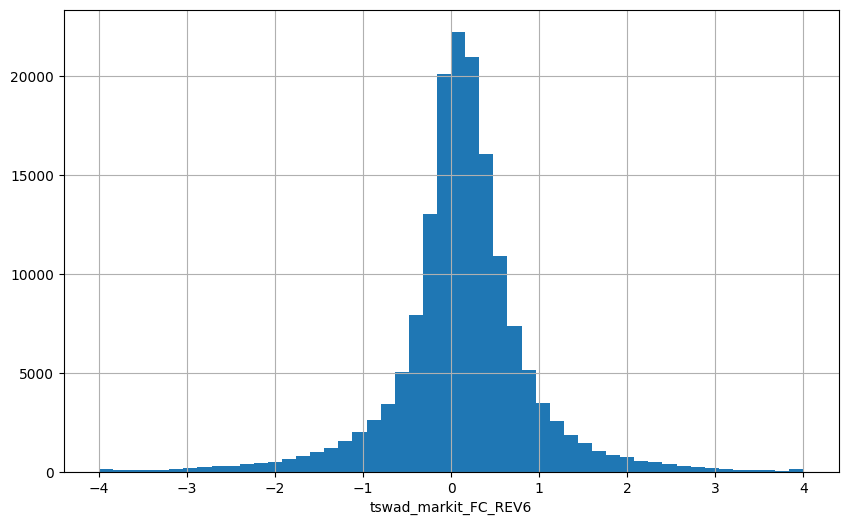

In [20]:
###### feature 15: tswad_markit_FC_REV6
varname = 'markit_FC_REV6'
var = data['load_simvar_hhmm'](varname)
tswad_var =  op.at_nan2zero(ts_wtd_avg_diff(op.ts_fill(var), 3, 21, 'equal'))
tswad_var = op.at_zero2nan(tswad_var)

tswad_var = normalize_features(tswad_var)

df['tswad_'+varname] = tswad_var[flatten_mask]

hist_show(df, 'tswad_'+varname)

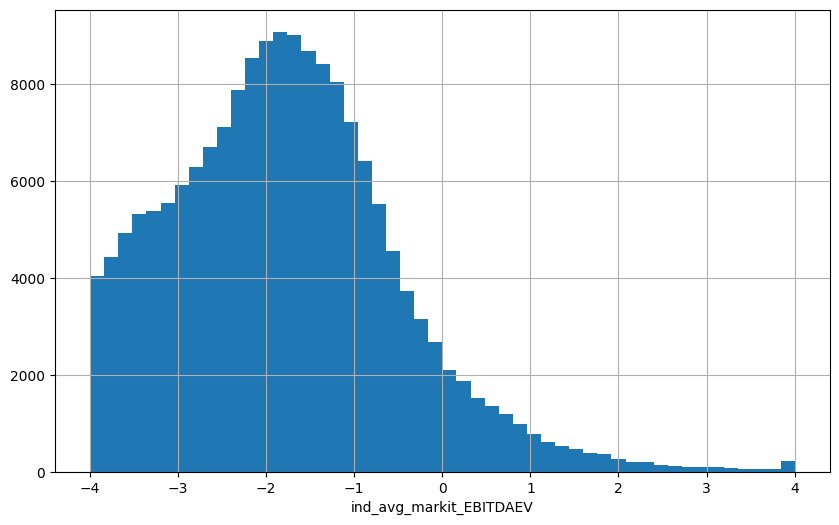

In [21]:
###### feature 16: ind_avg_markit_EBITDAEV
def ind_avg(variable, industry):
    output = np.full(variable.shape, np.nan)    
    temp = np.copy(variable)    
    # binary array based on the presence of NaN values 
    temp1 = 1.0 * (~np.isnan(temp))    
    # Set NaN values in temp to zero
    temp = op.at_nan2zero(temp)
    # iterating over dates
    for i in range(variable.shape[1]):
        col_values = temp[:, i]
        col_weights = temp1[:, i]
        col_industry = industry[:, i]
        # Calculate count, sum, and fraction of values per industry using bincount
        count = np.bincount(col_industry, weights=col_weights)
        value = np.bincount(col_industry, weights=col_values)
        fraction = value / count        
        output[:, i] = fraction[col_industry]
    return output

var = op.ts_fill(data['load_simvar_hhmm']("markit_EBITDAEV"))
var = op.ts_mean(var,63)
avg_var  = ind_avg(var,data['industry'])
neut_var = var/avg_var

neut_var = normalize_features(neut_var)

df['ind_avg_markit_EBITDAEV']= (neut_var)[flatten_mask]

hist_show(df, 'ind_avg_markit_EBITDAEV')

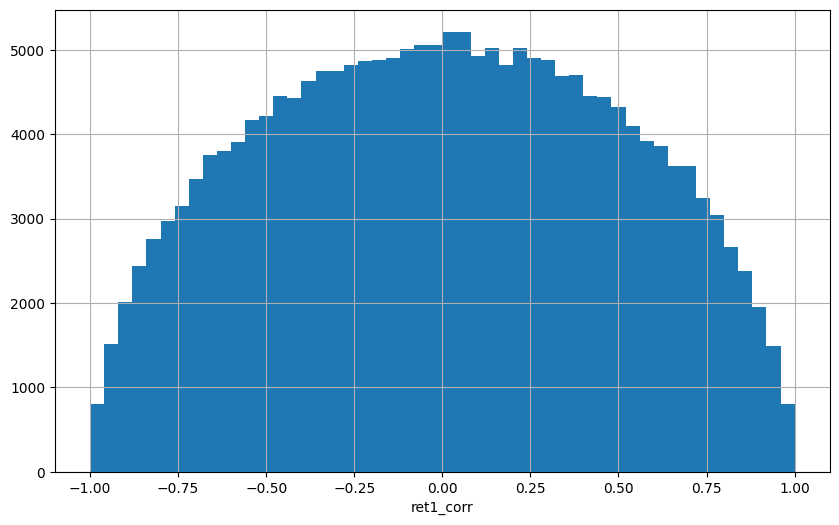

In [22]:
######## feature 17: Corr of returns
ret= op.ts_fill(data['load_simvar_hhmm']('ret1_excess'))
v=np.copy(ret)
n=5
a=np.zeros((ret.shape[0],n))
for i in range(1,n+1):
    a[:,i-1]=n+1-i
for i in range(n,ret.shape[1],1):
    v[:,i]=op.ts_corr_binary(ret[:,i-n:i],a,n)[:,n-1]

# v = normalize_features(v)

df['ret1_corr']=op.at_nan2zero(v)[flatten_mask]

hist_show(df, 'ret1_corr')

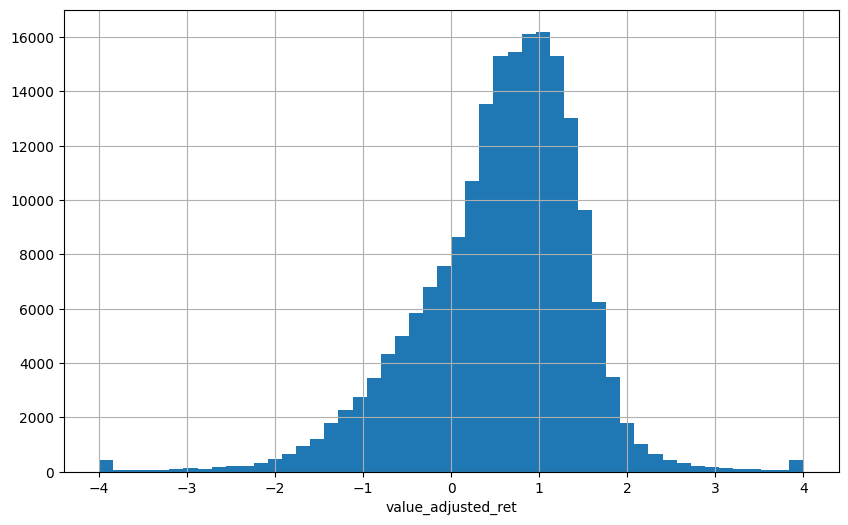

In [23]:
######## feature 18: Value adjusted return
from sklearn.linear_model import LinearRegression

model = LinearRegression()
value = op.ts_fill(data['load_simvar_hhmm']('barra_value'))
value = op.at_nan2zero(value)

s_ret = op.ts_fill(data['load_simvar_hhmm']('ret1'))
s_ret = op.at_nan2zero(s_ret)
results=np.copy(s_ret)

for i in range(value.shape[1]):
    r1=np.copy(value[:,i].reshape(-1,1))
    model.fit(value[:,i].reshape(-1,1),s_ret[:,i].reshape(-1,1))
    
    r1=model.predict(value[:,i].reshape(-1,1))
    r1=r1.reshape(r1.shape[0])
    results[:,i]=r1

residuals=s_ret-results
vol=op.ts_std(results,10)+1e-9
str=(residuals/vol)

str = normalize_features(str)

df['value_adjusted_ret'] = op.at_nan2zero(str)[flatten_mask]

hist_show(df, 'value_adjusted_ret')

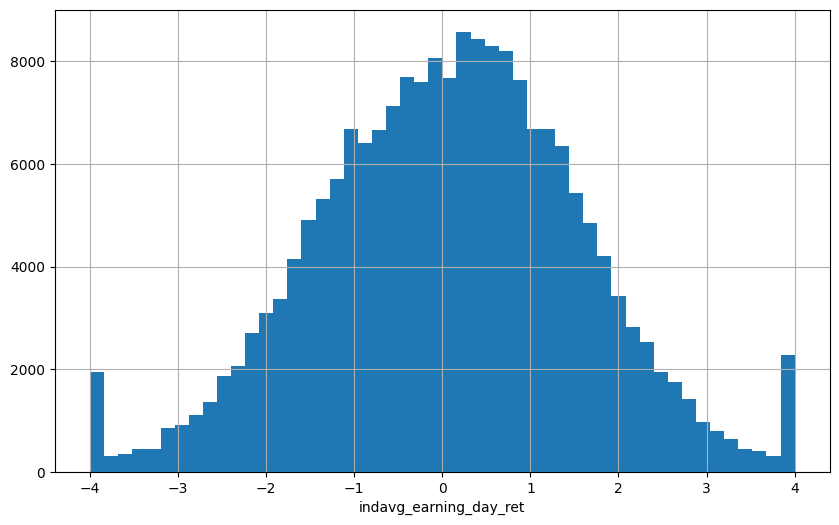

In [24]:
######## feature 19: ind_avg_returns
dates=data['dates']
data['quarter_of_the_year'] = data['load_simvar_hhmm']('quarter_of_the_year')
retvar = 'ret1_excess'

year = [date//10000 for date in dates]
last_ann_quarter = op.ts_fill(data['quarter_of_the_year']*(op.at_zero2nan(1.*flatten_mask)))
last_ann_year = op.ts_fill(year*(op.at_zero2nan(1.*flatten_mask)))

ann_is_same_quarter_mask = ((data['quarter_of_the_year'] == last_ann_quarter) & (year == last_ann_year))

prev_earning_day_ret = op.ts_fill(op.at_zero2nan(data['load_simvar_hhmm'](retvar)*op.ts_delay(1.*flatten_mask,1))) #delay to get the return on earnings day
earning_day_ret_same_quarter = prev_earning_day_ret*ann_is_same_quarter_mask

indavg_earning_day_ret = ind_avg(earning_day_ret_same_quarter,data['industry']) ##can try sector, subindustry and other groupings

indavg_earning_day_ret = normalize_features(indavg_earning_day_ret)

df['indavg_earning_day_ret'] = op.at_nan2zero(indavg_earning_day_ret)[flatten_mask]

hist_show(df, 'indavg_earning_day_ret')

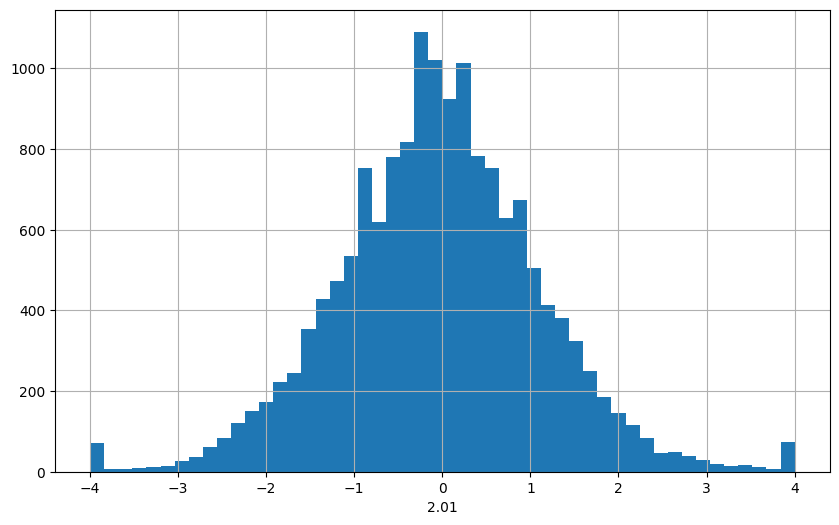

In [25]:
######### feature 20: news
def news(variable,da):
    a=(variable)/(1+da*da)
    a=op.ts_fill(a)
    a=op.ts_zscore(a,270)
    a=op.at_nan2zero(a)
    return a
    
pos_2_01=(data['load_simvar_hhmm']('edgar8k_finbert_pos_2_01'))
neg_2_01=(data['load_simvar_hhmm']('edgar8k_finbert_neg_2_01'))
neu_2_01=(data['load_simvar_hhmm']('edgar8k_finbert_neut_2_01'))

d=data['load_simvar_hhmm']('trading_days_til_next_ann')

feat = op.at_nan2zero(news(pos_2_01-neg_2_01,d))
feat = op.at_zero2nan(feat)

feat = normalize_features(feat)

df['2.01']=feat[flatten_mask]
hist_show(df, '2.01')

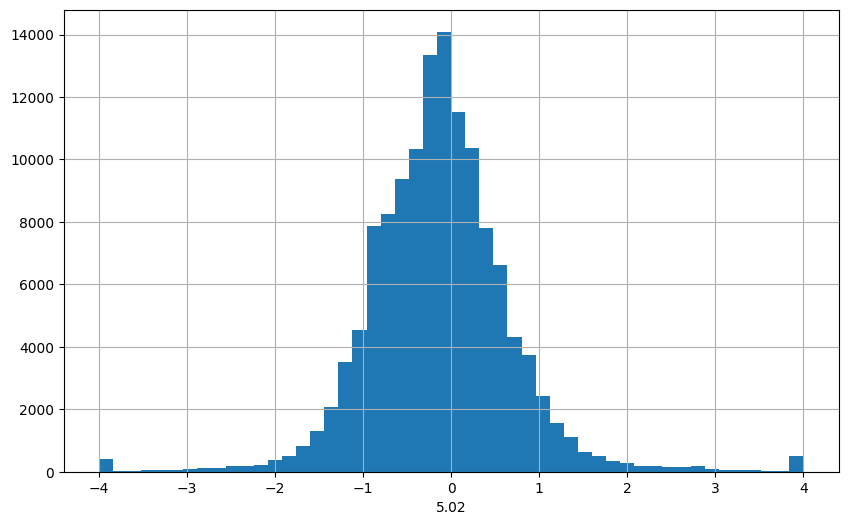

In [26]:
######### feature 21: news
pos_5_02=(data['load_simvar_hhmm']('edgar8k_finbert_pos_5_02'))
neg_5_02=(data['load_simvar_hhmm']('edgar8k_finbert_neg_5_02'))
neu_5_02=(data['load_simvar_hhmm']('edgar8k_finbert_neut_5_02'))

feat = op.at_nan2zero(news(pos_5_02-neg_5_02,d))
feat = op.at_zero2nan(feat)

feat = normalize_features(feat)

df['5.02']= feat[flatten_mask]
hist_show(df, '5.02')

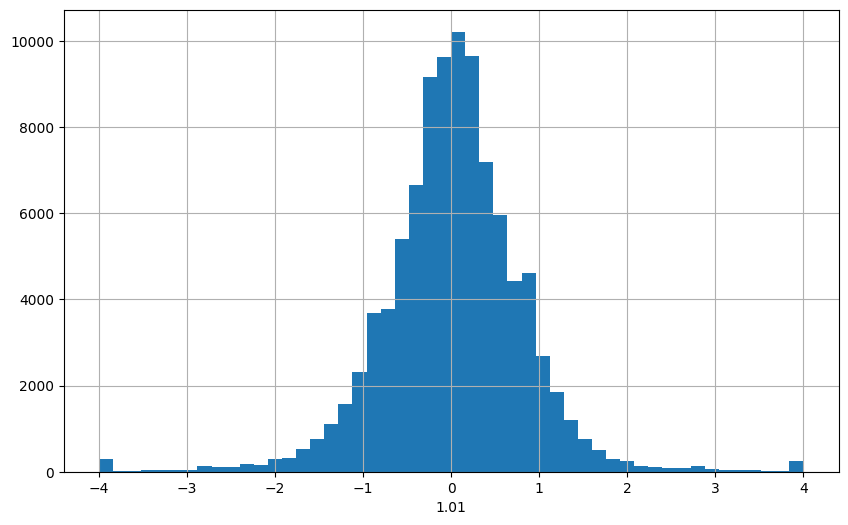

In [27]:
######### feature 22: news
neg_1_01=(data['load_simvar_hhmm']('edgar8k_finbert_neg_1_01'))
pos_1_01=(data['load_simvar_hhmm']('edgar8k_finbert_pos_1_01'))

feat = op.at_nan2zero(news(pos_1_01-neg_1_01,d))
feat = op.at_zero2nan(feat)

feat = normalize_features(feat)

df['1.01']=feat[flatten_mask]
hist_show(df, '1.01')

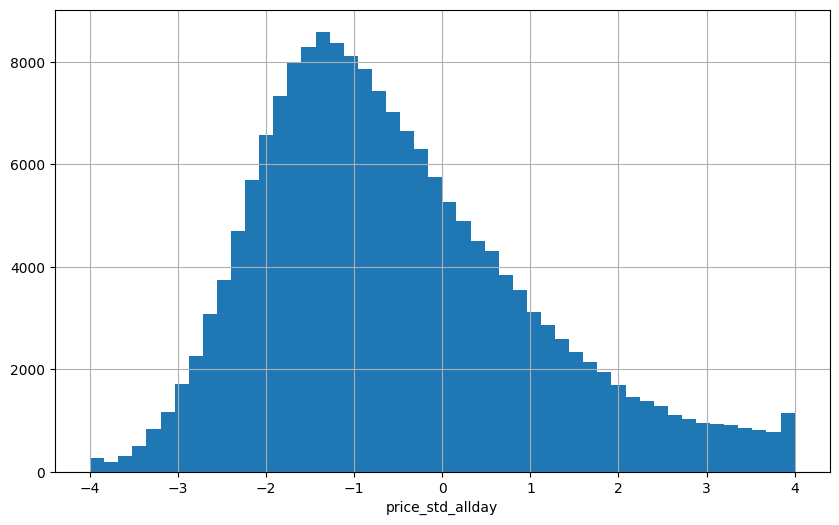

In [28]:
######### feature 23: intra tech
price_std_allday = data['load_simvar_hhmm']('price_std_allday')
feat = (op.ts_zscore(price_std_allday, 21))

feat = normalize_features(feat)

df['price_std_allday'] = feat[flatten_mask]
hist_show(df, 'price_std_allday')

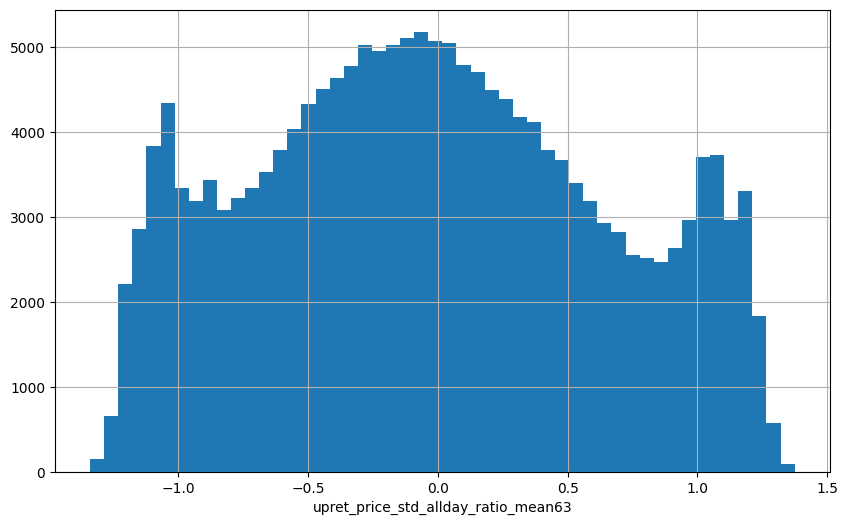

In [29]:
######### feature 24: intra tech
upret_price_std_allday = data['load_simvar_hhmm']('upret_price_std_allday')

feat = (op.cs_winsor(op.cs_zscore((op.ts_mean(upret_price_std_allday/price_std_allday, 63))), 0.1))
# feat = normalize_features(feat)

df['upret_price_std_allday_ratio_mean63'] = feat[flatten_mask]
hist_show(df, 'upret_price_std_allday_ratio_mean63')

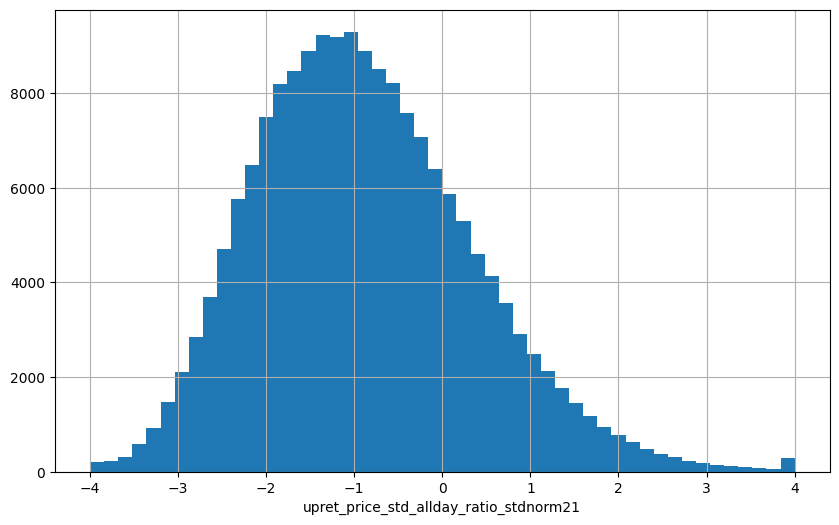

In [30]:
######### feature 25: intra tech
downret_price_std_allday = data['load_simvar_hhmm']('downret_price_std_allday')
feat = (np.clip(op.ts_std_normalized(upret_price_std_allday/price_std_allday, 21), 0, 17))
feat = normalize_features(feat)

df['upret_price_std_allday_ratio_stdnorm21'] = feat[flatten_mask]
hist_show(df, 'upret_price_std_allday_ratio_stdnorm21')


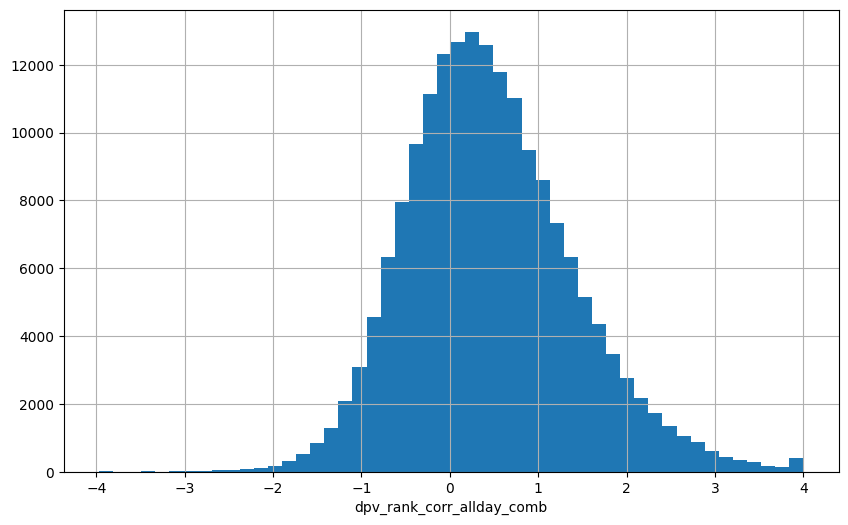

In [31]:
######### feature 26: intra tech
def ts_ols_v(y, days, stat='beta_1'):
    res = np.ones_like(y).astype(np.float32)
    res[:, :] = np.nan
    t = np.arange(days)
    y_bar = op.ts_mean(y, days)
    s2_y = op.ts_std(y, days)**2*((days-1)/days)
    s_yt = np.zeros_like(y).astype(np.float32)
    t_bar = t.mean()
    s2_t = t.var()
    for i in range(days):
        s_yt += (op.ts_delay(y, i) - y_bar)*(t[-i-1]-t_bar)
    s_yt /= days

    beta_0 = y_bar / days
    beta_1 = s_yt / s2_t
    if stat=='beta_0':
        return beta_0
    elif stat=='beta_1':
        return beta_1
    elif stat=='pred':
        pred = beta_0 + beta_1*(days)
        return pred
    elif stat=='R2':
        R2 = (s_yt / np.sqrt((s2_t*s2_y)))**2
        return R2

dpv_rank_corr_allday = op.ts_fill(data['load_simvar_hhmm']('dpv_rank_corr_allday').astype(np.float32))
dpv_rank_corr_allday_std = op.ts_std(dpv_rank_corr_allday, 10)
dpv_rank_corr_allday_comb = op.at_nan2zero(op.cs_zscore(dpv_rank_corr_allday)+op.cs_zscore(dpv_rank_corr_allday_std))
dpv_rank_corr_allday_comb = op.at_zero2nan(dpv_rank_corr_allday_comb)

dpv_rank_corr_allday_comb = normalize_features(dpv_rank_corr_allday_comb)

df['dpv_rank_corr_allday_comb'] =  (dpv_rank_corr_allday_comb)[flatten_mask]
hist_show(df, 'dpv_rank_corr_allday_comb')


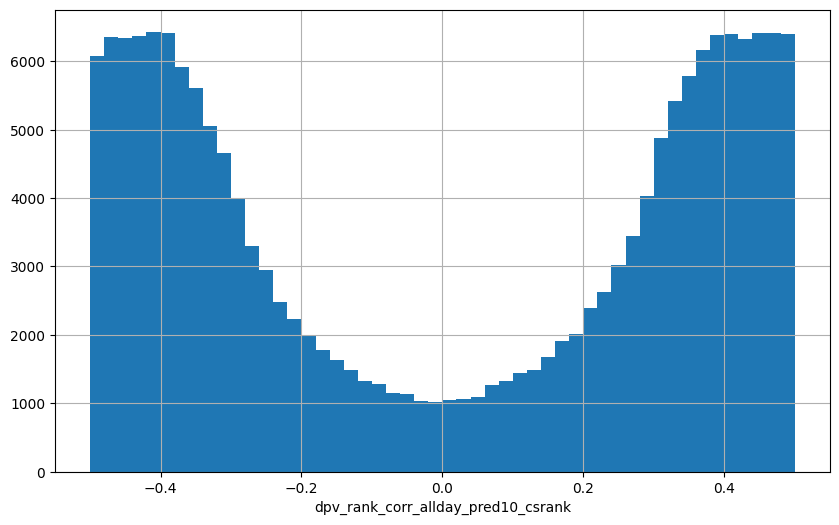

In [32]:
######### feature 27: intra tech
dpv_rank_corr_allday_pred10 = op.at_nan2zero(op.cs_rank(ts_ols_v(dpv_rank_corr_allday[:, :], days=10, stat='pred')))
dpv_rank_corr_allday_pred10 = op.at_zero2nan(dpv_rank_corr_allday_pred10)
dpv_rank_corr_allday_pred10 = dpv_rank_corr_allday_pred10-1.5
# dpv_rank_corr_allday_pred10 = normalize_features(dpv_rank_corr_allday_pred10)

df['dpv_rank_corr_allday_pred10_csrank'] =  (dpv_rank_corr_allday_pred10)[flatten_mask]
hist_show(df, 'dpv_rank_corr_allday_pred10_csrank')


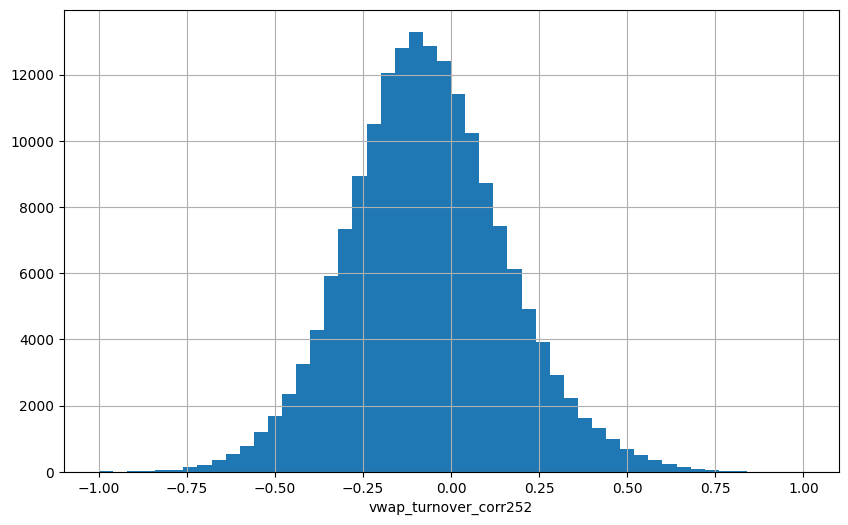

In [33]:
######### feature 28: tech
volume = op.ts_fill(data['load_simvar_hhmm']('volume').astype(np.float32))
shsfloat = op.ts_fill(data['load_simvar_hhmm']('shsfloat').astype(np.float32))
vwap = op.ts_fill(data['load_simvar_hhmm']('vwap').astype(np.float32))
turnover = volume / shsfloat
vwap_turnover_corr = (op.ts_corr_binary(vwap, turnover, 252))

# vwap_turnover_corr = normalize_features(vwap_turnover_corr)

df['vwap_turnover_corr252'] =  (vwap_turnover_corr)[flatten_mask]

hist_show(df, 'vwap_turnover_corr252')


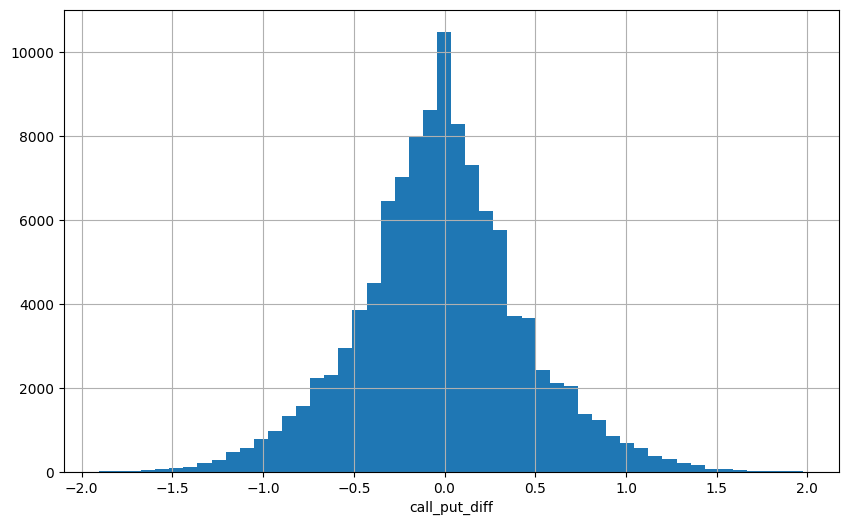

In [34]:
####### feature 29: option
call_buy_vol = data['load_simvar_hhmm']('nanex_option_2_call_num_trades_ab_mid')
call_sell_vol = data['load_simvar_hhmm']('nanex_option_2_call_num_trades_bl_mid')
put_buy_vol = data['load_simvar_hhmm']('nanex_option_2_put_num_trades_ab_mid')
put_sell_vol = data['load_simvar_hhmm']('nanex_option_2_put_num_trades_bl_mid')
call = (call_buy_vol-call_sell_vol)/(call_buy_vol+call_sell_vol)
put = (put_buy_vol-put_sell_vol)/(put_buy_vol+put_sell_vol)

feat = (call-put)

# feat = normalize_features(feat)

df['call_put_diff'] = feat[flatten_mask]
hist_show(df, 'call_put_diff')


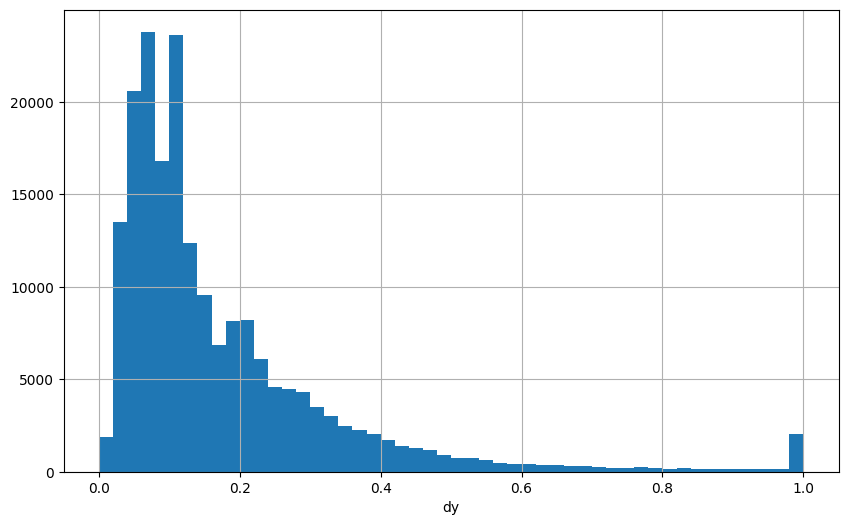

In [35]:
####### feature 30: fundamental, dvd yield
def group_mean(var, group):
    out = np.full(var.shape,np.nan)
    N,T = var.shape
    for t in (range(T)):
        df = pd.DataFrame({'var':var[:,t],'group': group[:,t]})
        df['group_mean'] = df.groupby('group')['var'].transform('mean')
        out[:,t] = df['group_mean'].values
    return out
    
sec = data['load_simvar_hhmm']('sector')

div_yield = op.ts_fill(data['load_simvar_hhmm']('ws_9404_q'))
div_yield_sec = group_mean(div_yield,sec)
div_yield_f = np.where(op.at_nan2zero(div_yield)==0,div_yield_sec,div_yield)

from scipy.stats.mstats import winsorize
# df['dy'] = op.at_nan2zero(winsorize(op.at_nan2zero(div_yield_f)[flatten_mask],limits=[0.0,0.01]))
# div_yield_f = normalize_features(div_yield_f)
div_yield_f = div_yield_f/100
div_yield_f[div_yield_f>0.1] = 0.1
div_yield_f = div_yield_f*10

df['dy'] = (div_yield_f)[flatten_mask]

hist_show(df, 'dy')


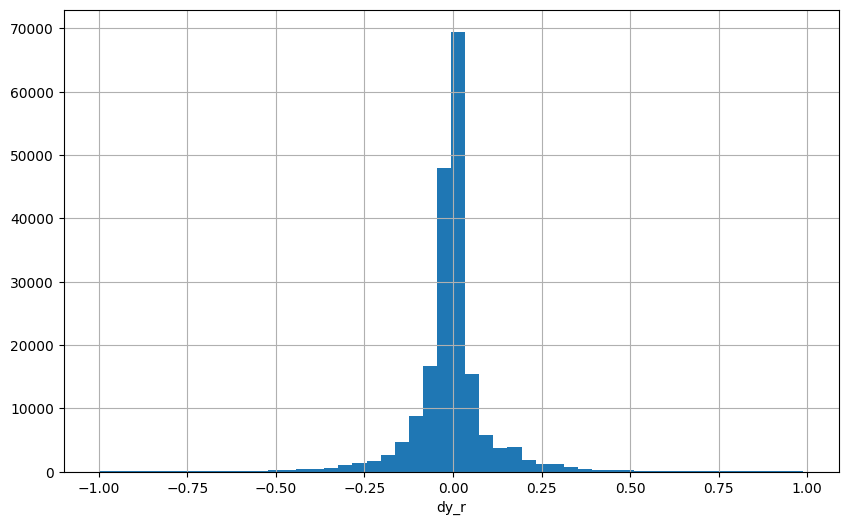

In [36]:
####### feature 31: fundamental, dvd yield

# num = op.at_zero2nan(div_yield_f)
den = op.at_nan2zero(op.ts_delay(div_yield_f,252)) - op.at_nan2zero(div_yield_f)
den = op.at_zero2nan(den)

# feat =  ((num/den))
feat = den
# feat = normalize_features(feat)

# feat = op.at_zero2nan(feat)

df['dy_r'] =feat[flatten_mask]

hist_show(df, 'dy_r')


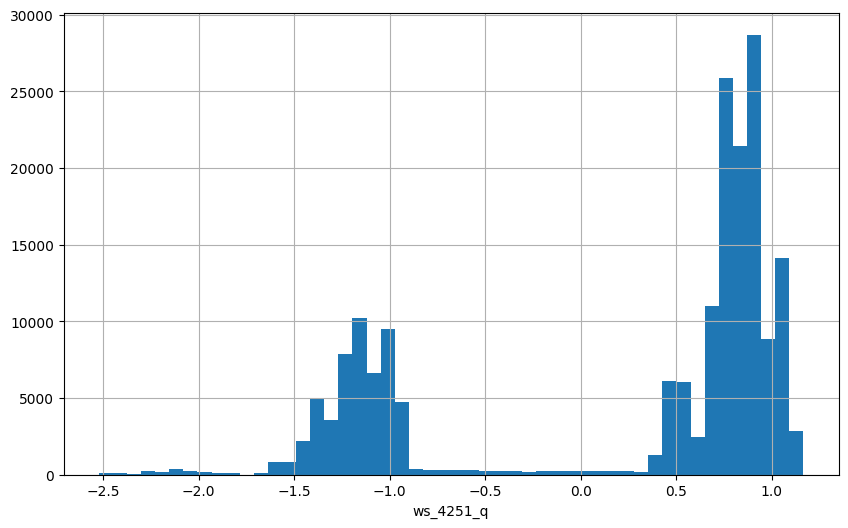

In [37]:
####### feature 32: fundamental, dvd yield
ws_4251_q = data['load_simvar_hhmm']('ws_4251_q')
ws_4251_q[ws_4251_q>0.1] = 0.1
ws_4251_q[ws_4251_q<0] = 0
ws_4251_q = op.cs_zscore(op.ts_fill(ws_4251_q))

# ws_4251_q = normalize_features(ws_4251_q)

df['ws_4251_q'] = (ws_4251_q)[flatten_mask]
hist_show(df, 'ws_4251_q')


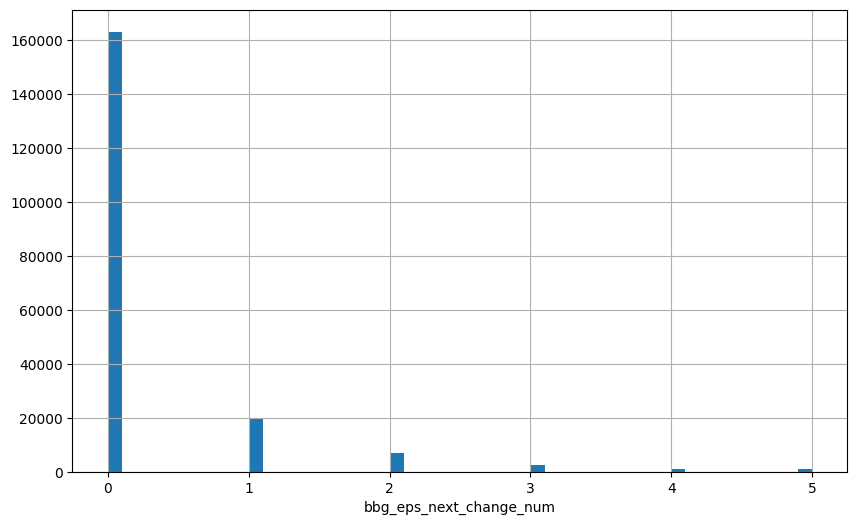

In [38]:
####### feature 33: analyst, eps chgs
bbg_eps_next_change_num = data['load_simvar_hhmm']('bbg_eps_next_change_num')
bbg_eps_next_change_num[bbg_eps_next_change_num<0] = 0.0
bbg_eps_next_change_num[bbg_eps_next_change_num>5] = 5

# bbg_eps_next_change_num = op.cs_zscore(op.ts_fill(bbg_eps_next_change_num))
bbg_eps_next_change_num = (op.ts_fill(bbg_eps_next_change_num))

# bbg_eps_next_change_num = op.at_zero2nan(bbg_eps_next_change_num)
# bbg_eps_next_change_num = normalize_features(bbg_eps_next_change_num)

df['bbg_eps_next_change_num'] = (bbg_eps_next_change_num)[flatten_mask]

hist_show(df, 'bbg_eps_next_change_num')


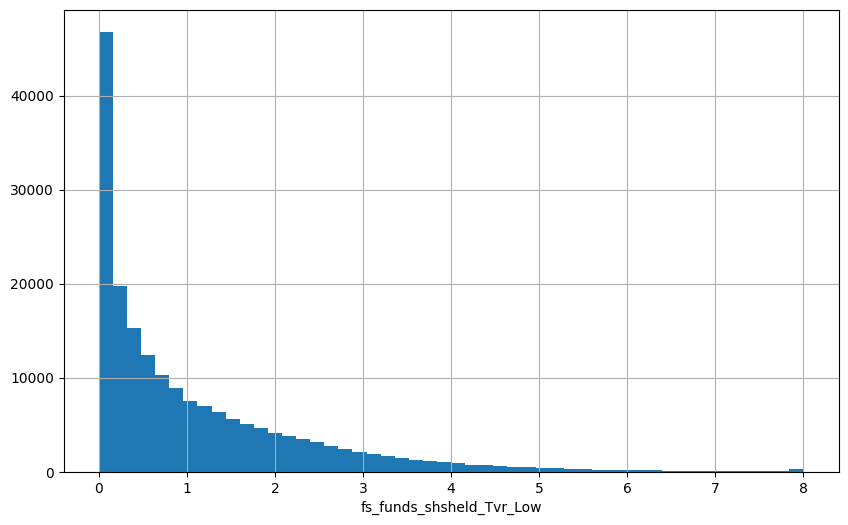

In [39]:
####### feature 34: held by funds
fs_funds_shsheld_Tvr_Low = data['load_simvar_hhmm']('fs_funds_shsheld_Tvr_Low')
fs_funds_shsheld_Tvr_Low = op.cs_zscore(op.ts_fill(fs_funds_shsheld_Tvr_Low))

fs_funds_shsheld_Tvr_Low = normalize_features(fs_funds_shsheld_Tvr_Low) + 4

df['fs_funds_shsheld_Tvr_Low'] = (fs_funds_shsheld_Tvr_Low)[flatten_mask]

hist_show(df, 'fs_funds_shsheld_Tvr_Low')


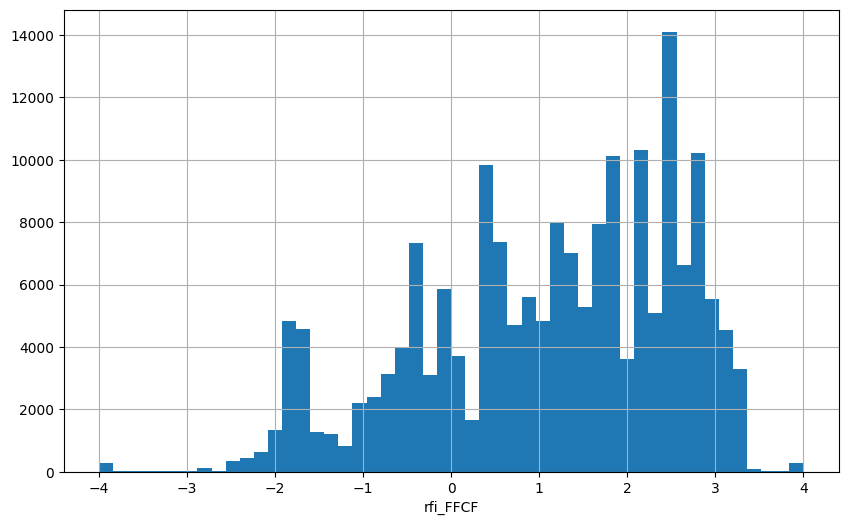

In [40]:
####### feature 35: fundamental
rfi_FFCF = data['load_simvar_hhmm']('rfi_FFCF')
rfi_FFCF = op.cs_zscore(op.ts_fill(rfi_FFCF))

rfi_FFCF = normalize_features(rfi_FFCF)

df['rfi_FFCF'] = (rfi_FFCF)[flatten_mask]

hist_show(df, 'rfi_FFCF')


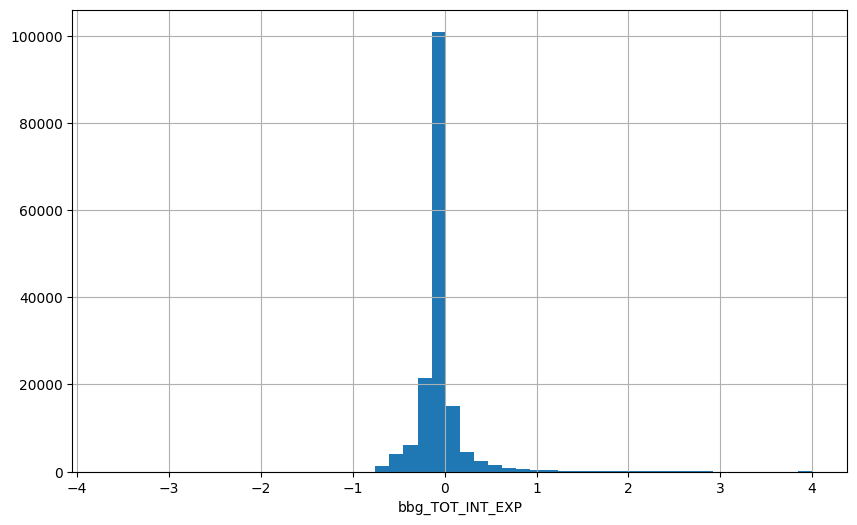

In [41]:
####### feature 36: fundamental
bbg_TOT_INT_EXP = data['load_simvar_hhmm']('bbg_TOT_INT_EXP')/data['load_simvar_hhmm']('bbg_ARD_TOT_ASSETS')
bbg_TOT_INT_EXP = op.cs_zscore(op.ts_fill(bbg_TOT_INT_EXP))
bbg_TOT_INT_EXP = op.at_zero2nan(bbg_TOT_INT_EXP)
bbg_TOT_INT_EXP[bbg_TOT_INT_EXP>4] = 4
bbg_TOT_INT_EXP[bbg_TOT_INT_EXP<-4] = -4

# bbg_TOT_INT_EXP = normalize_features(bbg_TOT_INT_EXP)

df['bbg_TOT_INT_EXP'] = (bbg_TOT_INT_EXP)[flatten_mask]

hist_show(df, 'bbg_TOT_INT_EXP')


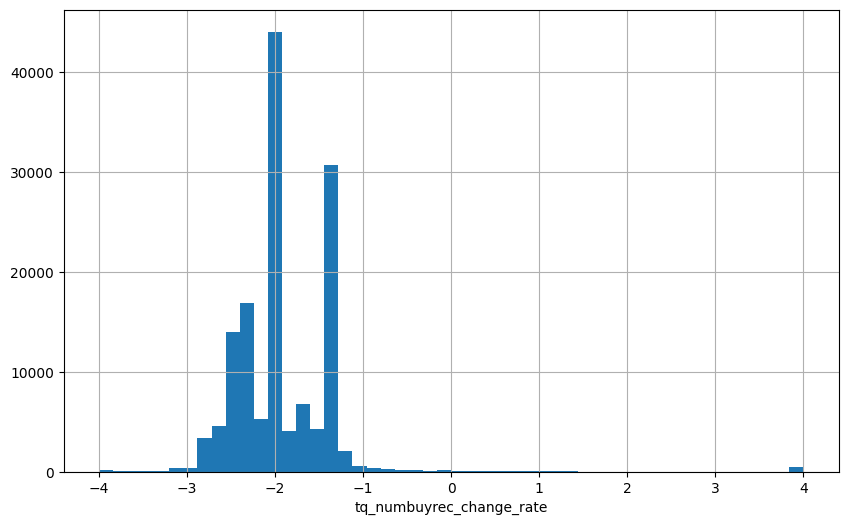

In [42]:
####### feature 37: chg of total number of buy recommendations
tq_numbuyrec_change_rate = data['load_simvar_hhmm']('tq_numbuyrec_change_rate')
tq_numbuyrec_change_rate = op.cs_zscore(op.ts_fill(tq_numbuyrec_change_rate))

tq_numbuyrec_change_rate = normalize_features(tq_numbuyrec_change_rate)


df['tq_numbuyrec_change_rate'] = (tq_numbuyrec_change_rate)[flatten_mask]

hist_show(df, 'tq_numbuyrec_change_rate')


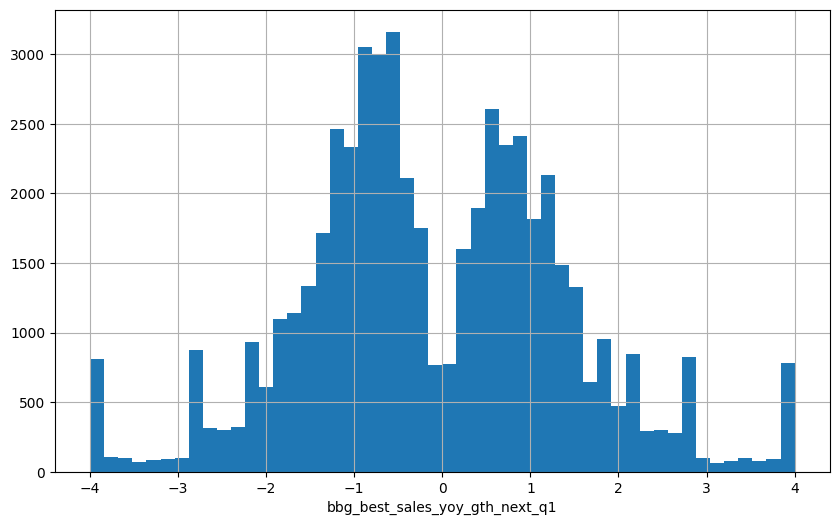

In [43]:
####### feature 38: analyst
bbg_best_sales_yoy_gth_next_q1 = data['load_simvar_hhmm']('bbg_best_sales_yoy_gth_next_q1')
bbg_best_sales_yoy_gth_next_q1 = (op.ts_zscore(op.ts_fill(bbg_best_sales_yoy_gth_next_q1), 21))

bbg_best_sales_yoy_gth_next_q1 = normalize_features(bbg_best_sales_yoy_gth_next_q1)

df['bbg_best_sales_yoy_gth_next_q1'] = (bbg_best_sales_yoy_gth_next_q1)[flatten_mask]

hist_show(df, 'bbg_best_sales_yoy_gth_next_q1')


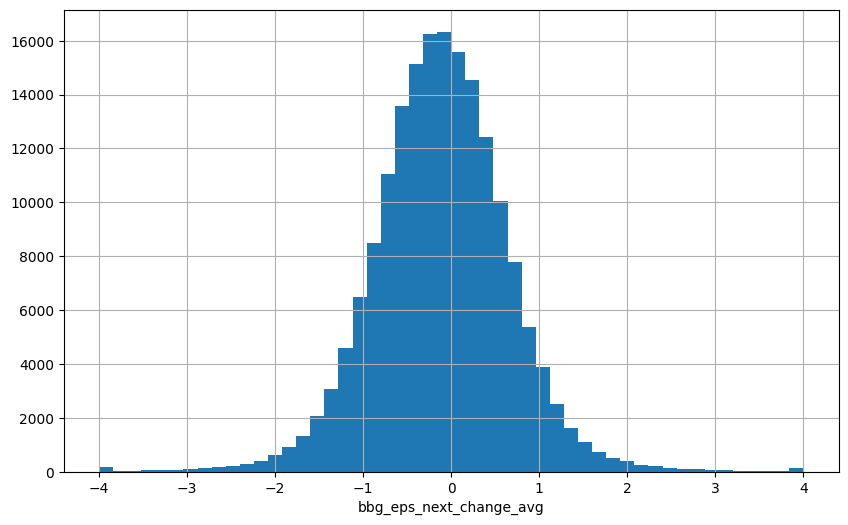

In [44]:
####### feature 39: analyst
bbg_eps_next_change_avg = data['load_simvar_hhmm']('bbg_eps_next_change_avg')
bbg_eps_next_change_avg = op.at_nan2zero(op.ts_zscore(op.ts_fill(bbg_eps_next_change_avg), 80))
bbg_eps_next_change_avg = op.at_zero2nan(bbg_eps_next_change_avg)

bbg_eps_next_change_avg = normalize_features(bbg_eps_next_change_avg)

df['bbg_eps_next_change_avg'] = (bbg_eps_next_change_avg)[flatten_mask]

hist_show(df, 'bbg_eps_next_change_avg')


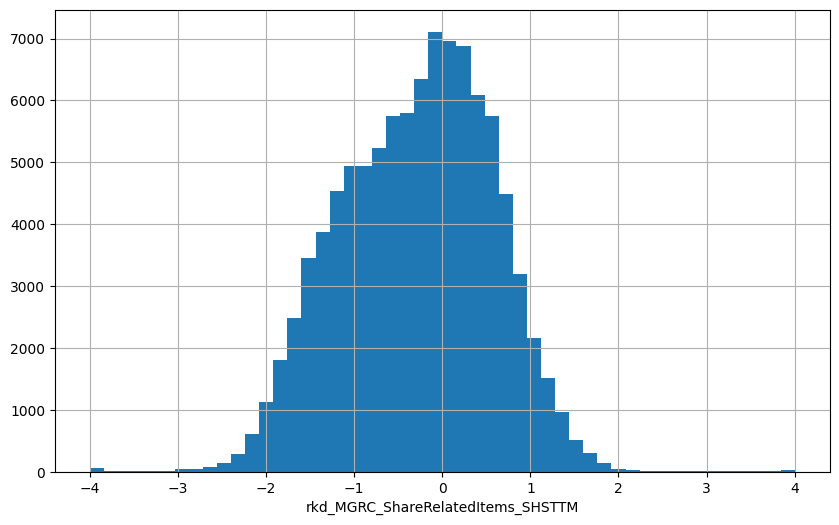

In [45]:
####### feature 40: shsout
rkd_MGRC_ShareRelatedItems_SHSTTM = data['load_simvar_hhmm']('rkd_MGRC_ShareRelatedItems_SHSTTM')
rkd_MGRC_ShareRelatedItems_SHSTTM = op.at_nan2zero(op.ts_zscore(op.ts_fill(rkd_MGRC_ShareRelatedItems_SHSTTM), 252))
rkd_MGRC_ShareRelatedItems_SHSTTM = op.at_zero2nan(rkd_MGRC_ShareRelatedItems_SHSTTM)

rkd_MGRC_ShareRelatedItems_SHSTTM = normalize_features(rkd_MGRC_ShareRelatedItems_SHSTTM)

df['rkd_MGRC_ShareRelatedItems_SHSTTM'] = (rkd_MGRC_ShareRelatedItems_SHSTTM)[flatten_mask]

hist_show(df, 'rkd_MGRC_ShareRelatedItems_SHSTTM')


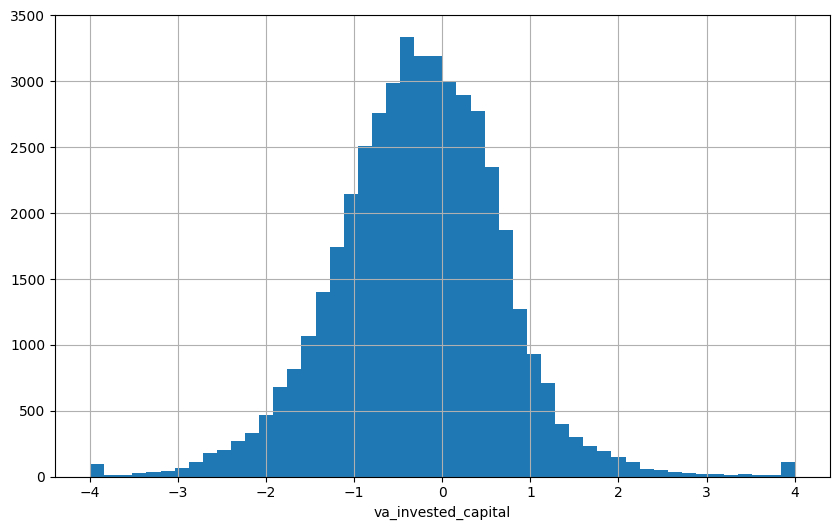

In [46]:
####### feature 41: fundamental, Invested capital
va_invested_capital = data['load_simvar_hhmm']('va_invested_capital')
va_invested_capital = op.at_nan2zero(op.ts_zscore(op.ts_fill(va_invested_capital), 252))
va_invested_capital = op.at_zero2nan(va_invested_capital)

va_invested_capital = normalize_features(va_invested_capital)

df['va_invested_capital'] = (va_invested_capital)[flatten_mask]

hist_show(df, 'va_invested_capital')


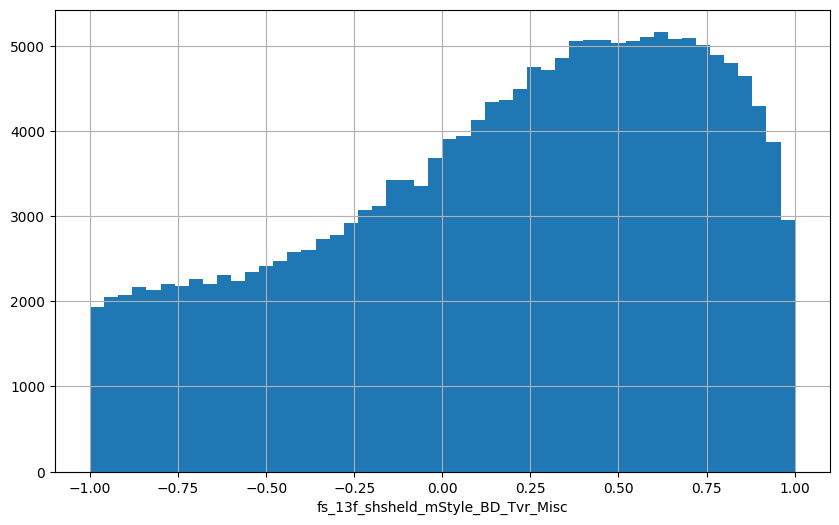

In [47]:
####### feature 42: held by funds
fs_13f_shsheld_mStyle_BD_Tvr_Misc = data['load_simvar_hhmm']('fs_13f_shsheld_mStyle_BD_Tvr_Misc')
fs_13f_shsheld_mStyle_BD_Tvr_Misc = op.cs_rank(op.ts_fill(fs_13f_shsheld_mStyle_BD_Tvr_Misc)) - 1.5
fs_13f_shsheld_mStyle_BD_Tvr_Misc = fs_13f_shsheld_mStyle_BD_Tvr_Misc*2

# fs_13f_shsheld_mStyle_BD_Tvr_Misc = normalize_features(fs_13f_shsheld_mStyle_BD_Tvr_Misc)

df['fs_13f_shsheld_mStyle_BD_Tvr_Misc'] = (fs_13f_shsheld_mStyle_BD_Tvr_Misc)[flatten_mask]
hist_show(df, 'fs_13f_shsheld_mStyle_BD_Tvr_Misc')


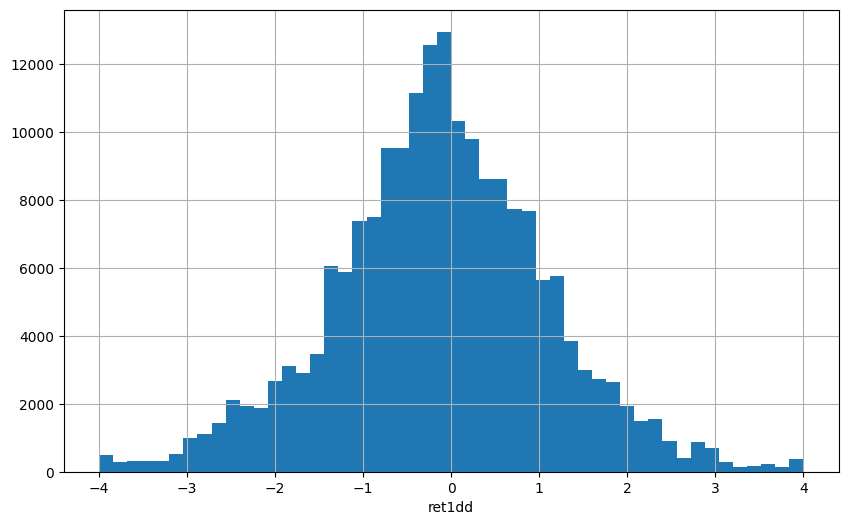

In [48]:
####### Feature 43: Mean Drawdown in ret1
def ts_cdar(tsr, lb):
    roll_max = op.ts_max(tsr, lb) 
    dd = roll_max/tsr - 1.
    cdar = op.ts_mean(dd, lb)
    return cdar

ret1 = data['load_simvar_hhmm']('ret1')
ret1 = op.at_nan2zero(ret1)
ret1dd = op.at_nan2zero(ts_cdar(ret1, 21))
ret1dd = op.at_zero2nan(ret1dd)

ret1dd = normalize_features(ret1dd)

df['ret1dd'] = ret1dd[flatten_mask]

hist_show(df, 'ret1dd')


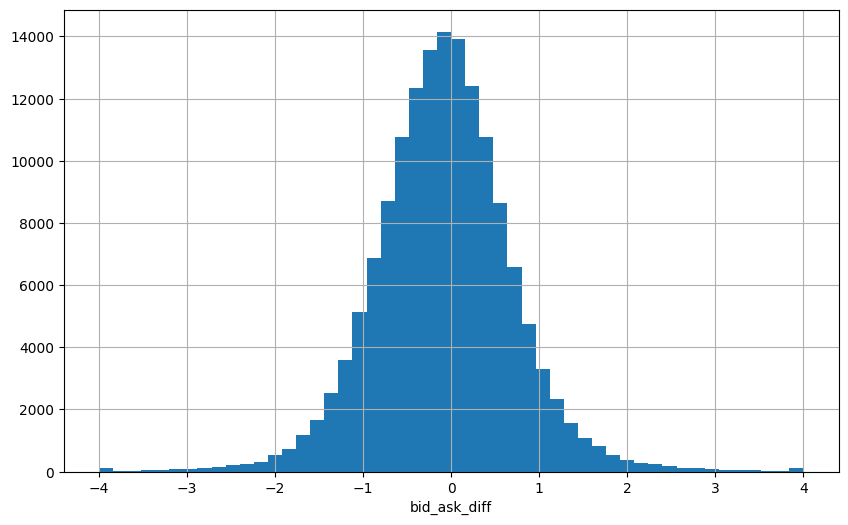

In [49]:
#### Feature 44: bid_ask_diff ####
bid_volume_allday = data['load_simvar_hhmm']('bid_volume_allday')
ask_volume_allday = data['load_simvar_hhmm']('ask_volume_allday')

bid_ask_diff = np.log(bid_volume_allday/ask_volume_allday)

bid_ask_diff = op.at_zero2nan(bid_ask_diff)
bid_ask_diff = normalize_features(bid_ask_diff)


df['bid_ask_diff'] = (bid_ask_diff)[flatten_mask]

hist_show(df, 'bid_ask_diff')


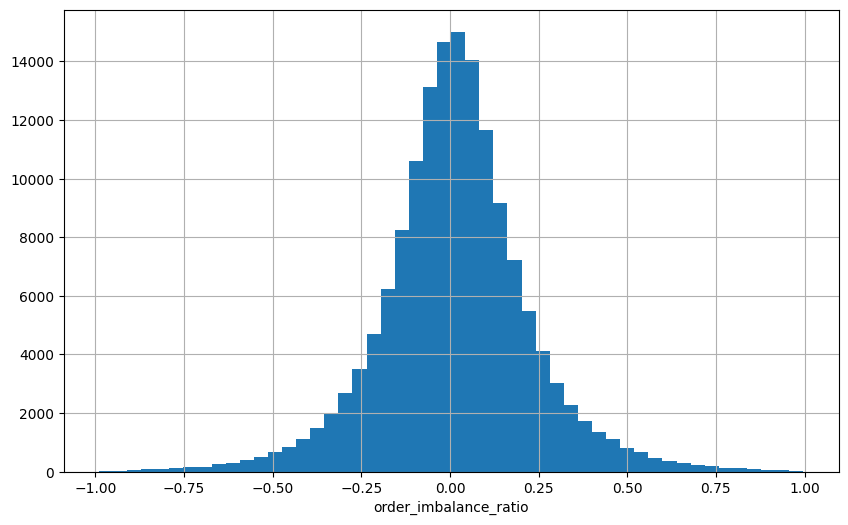

In [50]:
#### Feature 45: Order Imbalance Ratio
order_imbalance_ratio = bid_volume_allday/(bid_volume_allday + ask_volume_allday)
order_imbalance_ratio = order_imbalance_ratio-0.5
order_imbalance_ratio = order_imbalance_ratio*2
# order_imbalance_ratio = normalize_features(order_imbalance_ratio)


df['order_imbalance_ratio'] = (order_imbalance_ratio)[flatten_mask]
hist_show(df, 'order_imbalance_ratio')


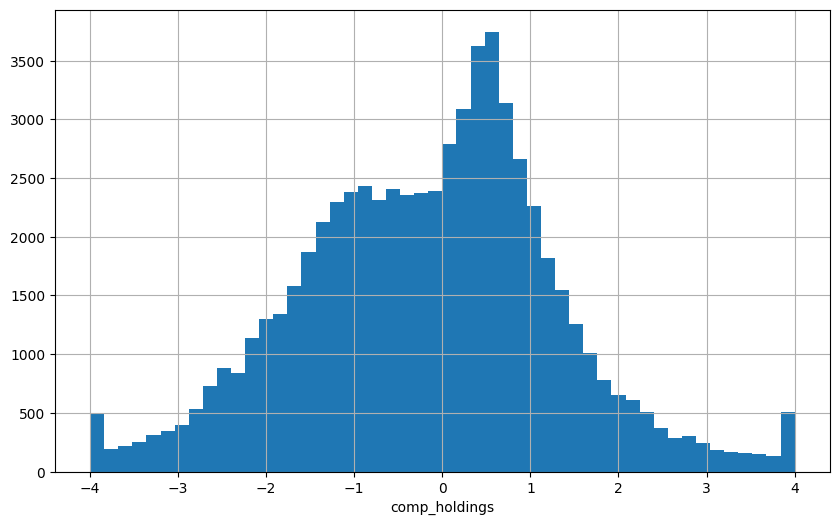

In [51]:
#### Feature 46: Holding in excess to competitor holding mean
def competitor_holding_sum(inp, relationship):
    out = np.full(inp.shape, np.nan, dtype=np.float32, order='F')    
    for di in range(len(relationship)):
        sub_relation = relationship[di].tocsr()
        indices = np.where(data['valid_stock_mask'])[0]
        sub_relation = sub_relation[np.ix_(indices, indices)]
        sum_holding = sub_relation.T.dot(inp[:,di])
        out[:,di] = sum_holding
    return out

def competitor_holding_mean(inp, relationship):
    out = np.full(inp.shape, np.nan, dtype=np.float32, order='F')        
    for di in range(len(relationship)):
        sub_relation = relationship[di].tocsr()
        indices = np.where(data['valid_stock_mask'])[0]
        sub_relation = sub_relation[np.ix_(indices, indices)]
        mean_holding = sub_relation.T.dot(inp[:,di]) / np.sum(sub_relation, axis=0)
        out[:,di] = mean_holding
    return out
    
edgar13F_all_filing_holdings_value_sum = data['load_simvar_hhmm']('edgar13F_all_filing_holdings_value_sum')
bbg_splc_competitor = data['load_simvar_hhmm']('bbg_splc_competitor')

holdings = op.at_nan2zero(edgar13F_all_filing_holdings_value_sum)
comp_holding_sum = competitor_holding_sum(holdings, bbg_splc_competitor)
comp_holding_mean = competitor_holding_mean(holdings, bbg_splc_competitor)

var = holdings - (comp_holding_mean)
comp_holdings = op.at_nan2zero(op.ts_zscore(var, 43))
comp_holdings = op.at_zero2nan(comp_holdings)
comp_holdings = normalize_features(comp_holdings)

df['comp_holdings'] = (comp_holdings)[flatten_mask]
hist_show(df, 'comp_holdings')


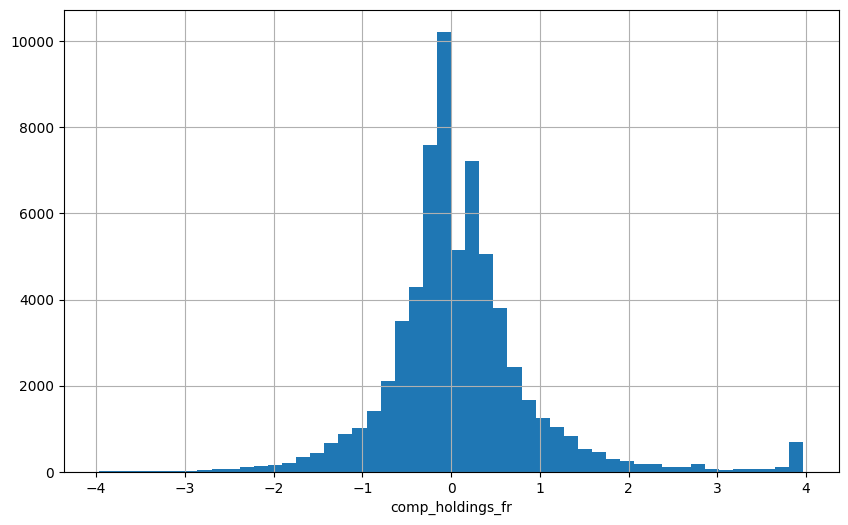

In [52]:
#### Feature 47: Fractional holding wrt to competitor holdings
varf = (holdings/(comp_holding_sum + holdings))
comp_holdings_fr = op.at_zero2nan(op.ts_zscore(varf, 65))
comp_holdings_fr = comp_holdings_fr/2

# comp_holdings_fr = normalize_features(comp_holdings_fr)


df['comp_holdings_fr'] = (comp_holdings_fr)[flatten_mask]
hist_show(df, 'comp_holdings_fr')


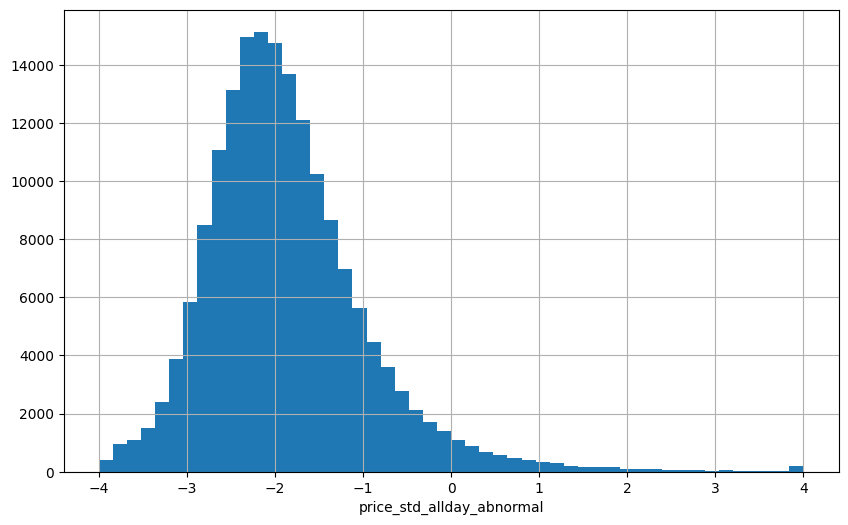

In [53]:
## Feature 48: Abnormal Price Std ##
def abnormal(inp, lb1, lb2):
    return op.ts_mean(inp, lb1) / op.ts_delay(op.ts_mean(inp, lb2), 21) - 1

price_std_allday = data['load_simvar_hhmm']('price_std_allday')
indicator1 = abnormal(price_std_allday, 2, 10)
indicator1 = op.at_zero2nan(indicator1)
indicator1 = normalize_features(indicator1)


df['price_std_allday_abnormal'] = (indicator1)[flatten_mask]

hist_show(df, 'price_std_allday_abnormal')


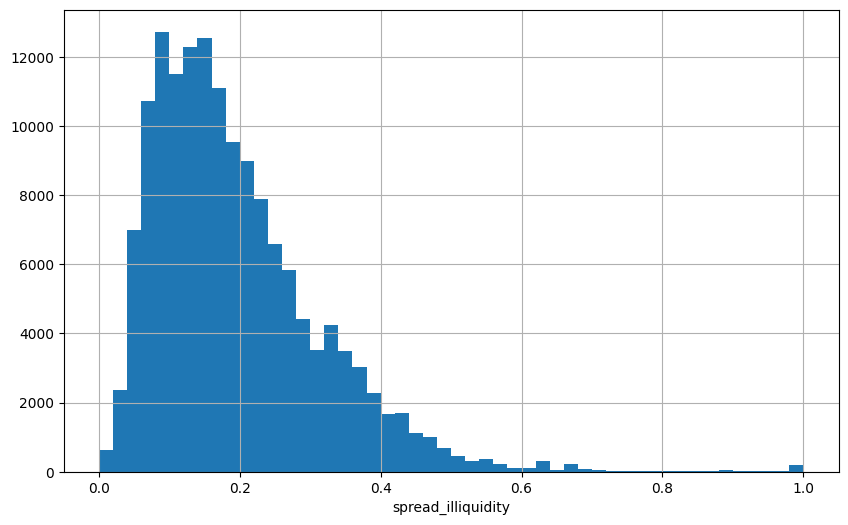

In [54]:
## Feature 49: Insider: Spread-Illiquidity
bid_allday = data['load_simvar_hhmm']('bid_allday')
ask_allday = data['load_simvar_hhmm']('ask_allday')
eapml_illiquidity = data['load_simvar_hhmm']('eapml_illiquidity')
spread = (ask_allday - bid_allday)/(ask_allday + bid_allday)
indicator = spread/eapml_illiquidity
indicator = op.at_zero2nan(indicator) 

indicator = (normalize_features(indicator) + 4)/8

df['spread_illiquidity'] = (indicator)[flatten_mask]

hist_show(df, 'spread_illiquidity')


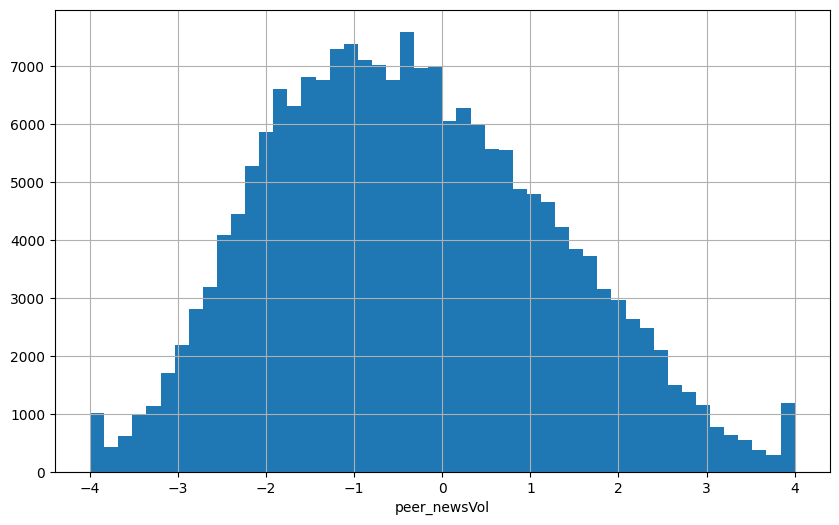

In [55]:
## Feature 50: Peer News Accumulation
import pandas as pd
def group_mean(var, group):
    var= op.at_nan2zero(var)
    [m, n]=var.shape
    alpha=np.full(var.shape,np.nan,dtype=np.float32,order='F')
    for di in range(n):
        group_sum = np.bincount(group[:, di], var[:, di]).astype(float)
        numstocks_group = op.at_zero2nan(np.bincount(group[:, di]).astype(float))
        alpha[:, di] = group_sum[group[:, di]] / numstocks_group[group[:, di]]
    return alpha

industry = data['load_simvar_hhmm']('industry')
trna_volume = data['load_simvar_hhmm']('trna_volume')
newsVol = op.ts_sum(trna_volume, 22)
peer_newsVol = op.ts_zscore(group_mean(newsVol, industry), 63)

peer_newsVol = normalize_features(peer_newsVol)

df['peer_newsVol'] = op.at_nan2zero(peer_newsVol)[flatten_mask]

hist_show(df, 'peer_newsVol')


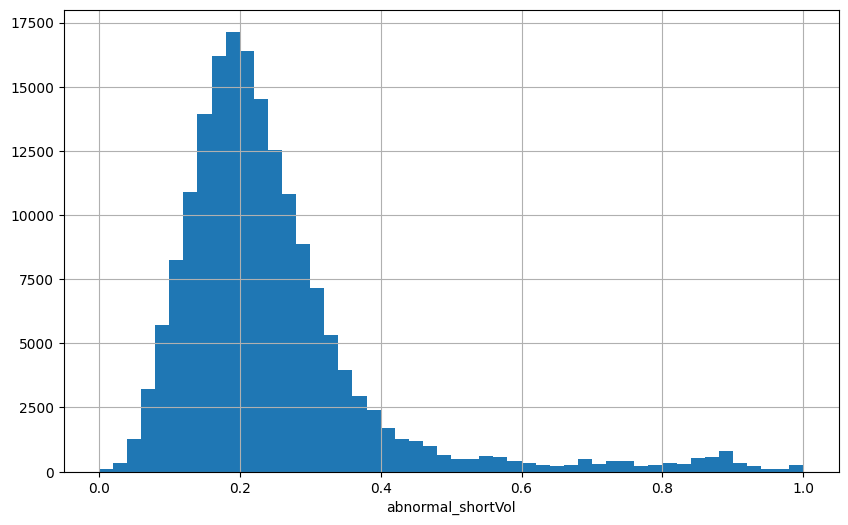

In [56]:
## Feature 51: Abnormal Short Volume
dailyshort_ShortVolumeRatio = data['load_simvar_hhmm']('dailyshort_ShortVolumeRatio')
industry = data['load_simvar_hhmm']('industry')
mean_shortVol = op.ts_delay(op.ts_mean(dailyshort_ShortVolumeRatio, 15), 21)
abnormal_shortVol = dailyshort_ShortVolumeRatio / mean_shortVol - 1
abnormal_shortVol = op.cs_indneut(abnormal_shortVol, industry)
abnormal_shortVol = op.at_zero2nan(abnormal_shortVol)

abnormal_shortVol = normalize_features(abnormal_shortVol)
abnormal_shortVol = (abnormal_shortVol + 4)/8

df['abnormal_shortVol'] = (abnormal_shortVol)[flatten_mask]

hist_show(df, 'abnormal_shortVol')


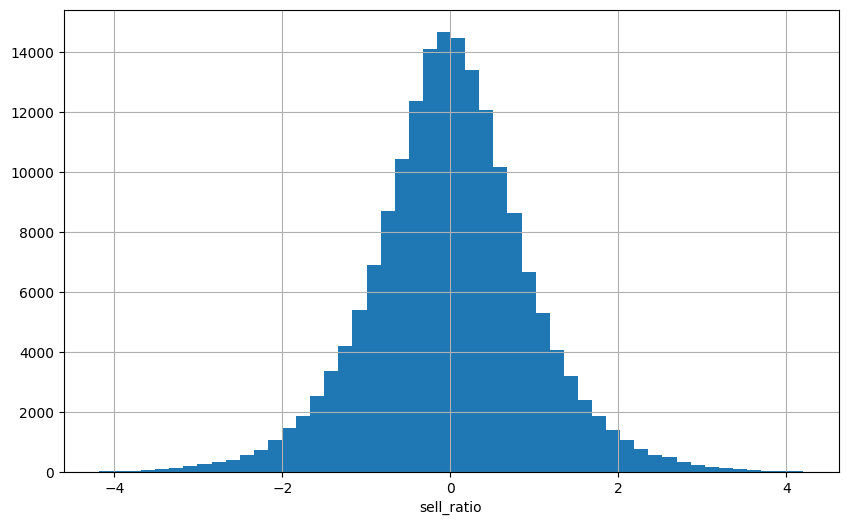

In [57]:
## Feature 52: Sell Ratio
tc_sell_shares_tick = data['load_simvar_hhmm']('tc_sell_shares_tick')
tc_buy_shares_tick = data['load_simvar_hhmm']('tc_buy_shares_tick')
sell_ratio = tc_sell_shares_tick / (tc_buy_shares_tick + tc_sell_shares_tick)
sell_ratio = (op.ts_zscore(sell_ratio, 21))

# abnormal_shortVol = normalize_features(abnormal_shortVol)

df['sell_ratio'] = (sell_ratio)[flatten_mask]

hist_show(df, 'sell_ratio')


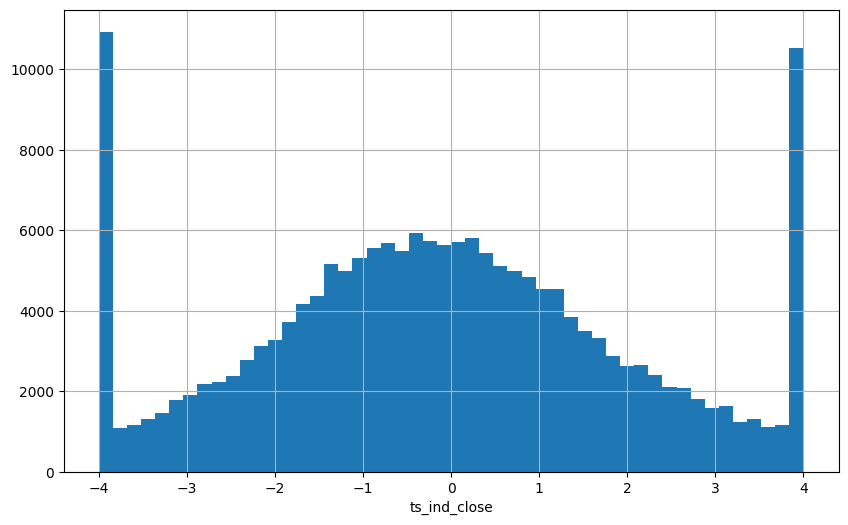

In [58]:
## Feature 53: group average
def group_median(preA, group):
    assert (preA.shape == group.shape)
    out = np.full(preA.shape, np.nan, dtype=np.float32, order='F')
    for di in range(preA.shape[1]):
        df = pd.DataFrame({'preA': preA[:, di], 'group': group[:, di]})
        out[:, [di]] = df.groupby('group').transform('median').values
    return out

def group_std(preA, group):
    assert (preA.shape == group.shape)
    out = np.full(preA.shape, np.nan, dtype=np.float32, order='F')
    for di in range(preA.shape[1]):
        df = pd.DataFrame({'preA': preA[:, di], 'group': group[:, di]})
        out[:, [di]] = df.groupby('group').transform('std').values
    return out

def only_ea(preA, flatten_mask, days=0):
    assert (preA.shape == flatten_mask.shape)
    out = np.full(preA.shape, np.nan, dtype=np.float32, order='F')
    if days == 0: 
        out = op.ts_fill(op.at_zero2nan(preA * (1.0 * flatten_mask)))
    else:
        valid_mask = op.ts_sum(1.0*flatten_mask, days) > 0
        out = op.ts_fill(op.at_zero2nan(preA * (1.0 * flatten_mask)))
        out = out * op.at_zero2nan(1.0 * valid_mask)
    return out
    
def ts_ret(preA, days):
    return (preA - op.ts_delay(preA, days)) / op.ts_delay(preA, days)
    
industry = data['load_simvar_hhmm']('industry')
ret1_excess = data['load_simvar_hhmm']('ret1_excess')
vwap = data['load_simvar_hhmm']('vwap_most_volume_15min_allday')
since = data['load_simvar_hhmm']('trading_days_since_last_ann') # lower bound ==1; 0/nan useless
ret1_excess = data['load_simvar_hhmm']('ret1_excess')
vwap = data['load_simvar_hhmm']('vwap_most_volume_15min_allday')

since_mask = (since == 1) & (flatten_mask == False)
ret1_vwap = ts_ret(vwap, 1)
ret_close_ea = only_ea(op.ts_mean(ret1_excess, 5)/op.ts_std(ret1_excess, 10), since_mask, 20)
ret_vwap_ea = only_ea(op.ts_mean(ret1_vwap, 5)/op.ts_std(ret1_vwap, 10), since_mask, 20)
g = industry
ind_avg_close = group_median(ret_close_ea, g)
ind_std_close = group_std(ret_close_ea, g)
ts_ind_close = ind_avg_close/ind_std_close
ts_ind_close = ts_ind_close/op.ts_std(ts_ind_close, 60)

feat = op.cs_winsor(ts_ind_close, 0.02, False)
feat = op.at_zero2nan(feat)
feat = normalize_features(feat)

df['ts_ind_close'] = feat[flatten_mask]

hist_show(df, 'ts_ind_close')


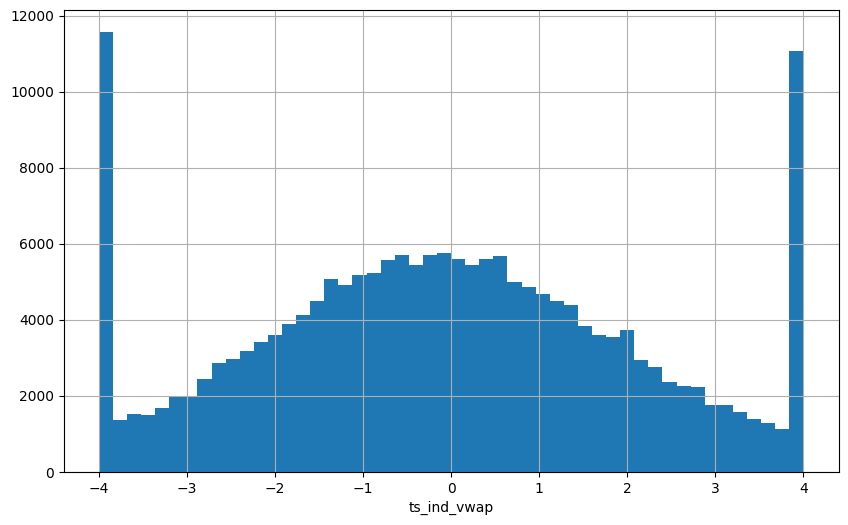

In [59]:
## Feature 54: group average
ind_avg_vwap = group_median(ret_vwap_ea, g)
ind_std_vwap = group_std(ret_vwap_ea, g)
ts_ind_vwap = ind_avg_vwap/ind_std_vwap
ts_ind_vwap = ts_ind_vwap/op.ts_std(ts_ind_vwap, 60)

feat =  op.at_nan2zero(op.cs_winsor(ts_ind_vwap, 0.02, False))

feat = normalize_features(feat)

df['ts_ind_vwap'] = feat[flatten_mask]
hist_show(df, 'ts_ind_vwap')


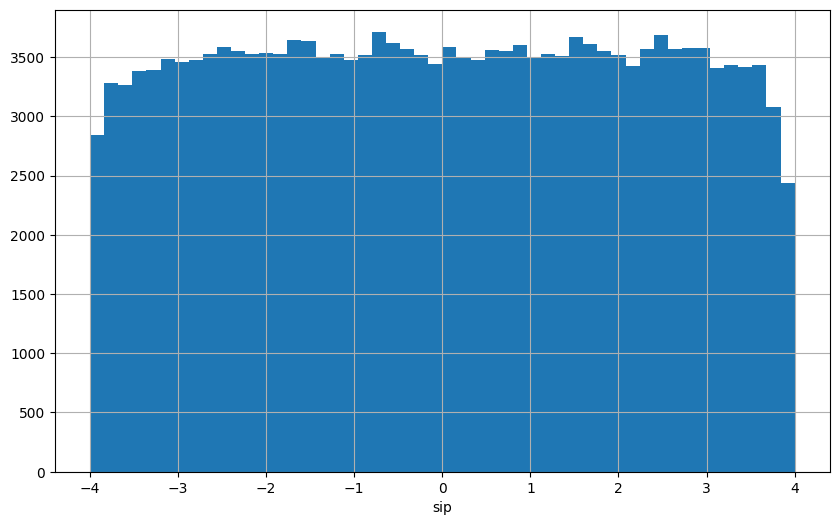

In [60]:
####### Feature 55: Short interest
sip = data['load_simvar_hhmm']('markit_MonChgSIP')

feat = op.at_nan2zero(op.ts_fill(sip))
feat = op.at_zero2nan(feat)

feat = normalize_features(feat)

df['sip'] = feat[flatten_mask]
hist_show(df, 'sip')


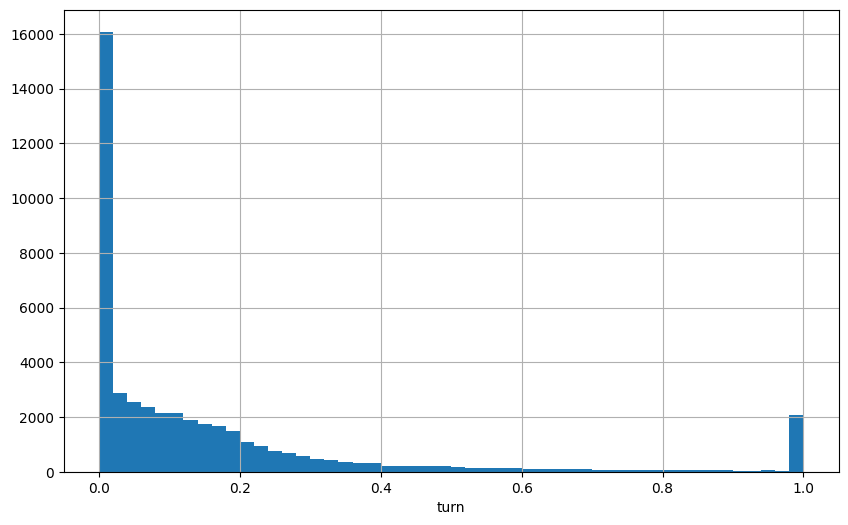

In [61]:
####### Feature 56: Investor disagreement
std = data['load_simvar_hhmm']('bbg_eps_next_change_std')
mean = data['load_simvar_hhmm']('bbg_eps_next_change_avg')

feat = op.at_nan2zero(op.ts_fill(std)/op.ts_fill(abs(mean)))
feat = op.at_zero2nan(feat)
feat = op.cs_winsor(feat,0.05)
feat = normalize_features(feat)
feat = (feat + 4)/8

df['turn'] = feat[flatten_mask]

hist_show(df, 'turn')


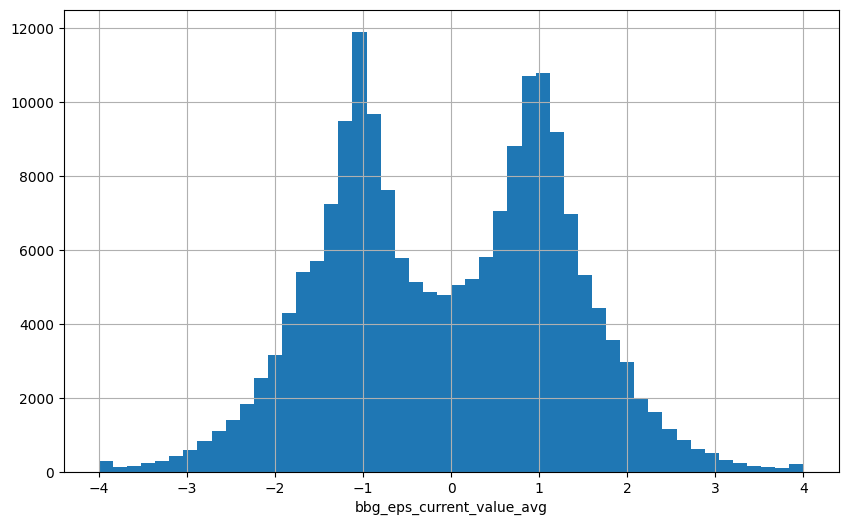

In [62]:
####### Feature 57: Analyst revision
bbg_eps_current_value_avg=data['load_simvar_hhmm']('bbg_eps_current_value_avg')

feat = op.at_nan2zero(op.ts_fill(op.ts_zscore(bbg_eps_current_value_avg,21)))
feat = op.at_zero2nan(feat)

feat = normalize_features(feat)

df["bbg_eps_current_value_avg"]= feat[flatten_mask]

hist_show(df, 'bbg_eps_current_value_avg')


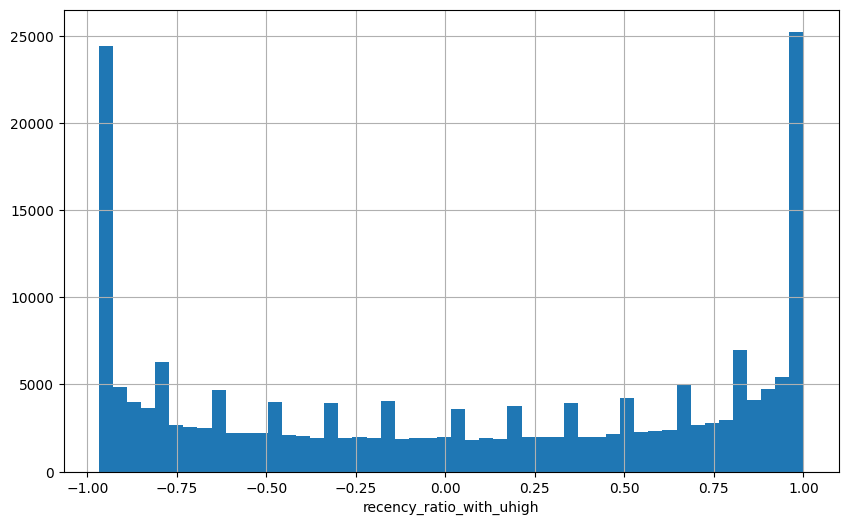

In [63]:
####### Feature 58: Change in EPS Surprise 
def ts_days_since_max(matrix, lookback):
    matrix = op.ts_fill(matrix)
    num_stocks, num_dates = matrix.shape
    argmax_matrix = np.zeros((num_stocks, num_dates))
    for t in range(num_dates):
        start = max(0, t - lookback + 1)
        end = t + 1
        current_window = matrix[:, start:end]
        max_indices = np.argmax(current_window, axis=1)
        relative_indices = t - (start + max_indices)
        argmax_matrix[:, t] = relative_indices
        nan_mask = np.isnan(current_window)
        all_nan_rows = nan_mask.all(axis=1)
        argmax_matrix[all_nan_rows, t] = int(lookback / 2)
    return argmax_matrix
    
featname = "recency_ratio_with_uhigh"
uhigh = data["load_simvar_hhmm"]("uhigh")
alpha = 1 - ts_days_since_max(uhigh, 63) / 63
alpha = op.at_nan2zero(alpha)
alpha = op.at_zero2nan(alpha) - 0.5
alpha = alpha*2

# alpha = normalize_features(alpha)

df[featname] = alpha[flatten_mask]
hist_show(df, featname)


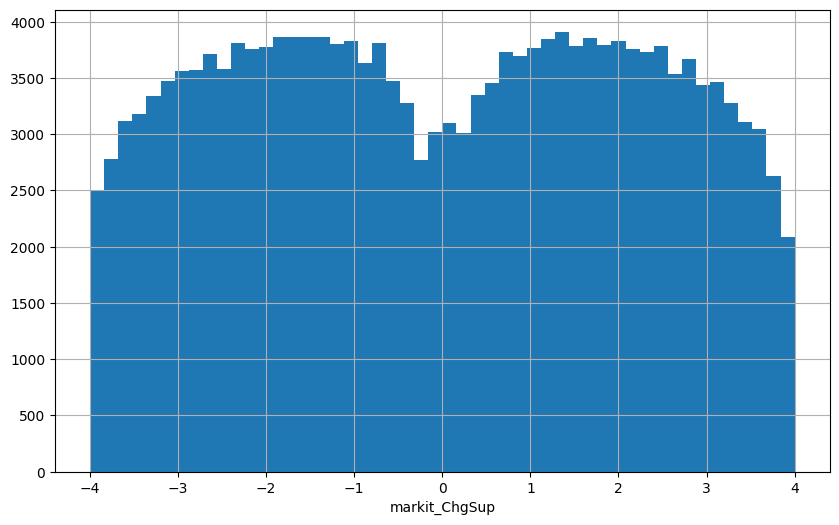

In [64]:
####### Feature 59: markit_ChgSup #Change in EPS Surprise
featname = "markit_ChgSup"
markit_ChgSup = data["load_simvar_hhmm"]("markit_ChgSup")
alpha = op.at_nan2zero(op.ts_fill(markit_ChgSup))
alpha = op.at_zero2nan(alpha)

alpha = normalize_features(alpha)

df[featname] = alpha[flatten_mask]

hist_show(df, featname)


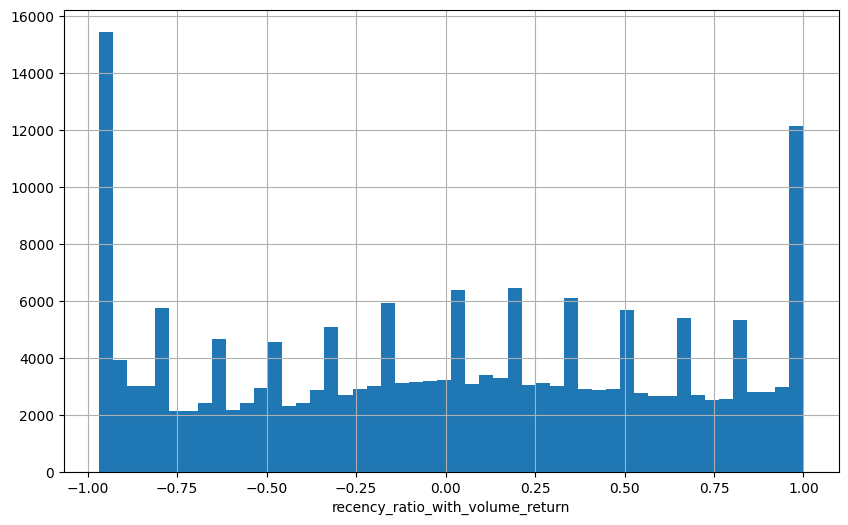

In [65]:
####### Feature 60: stdadj_volmret1_py
featname = "recency_ratio_with_volume_return"
stdadj_volmret1_py = data["load_simvar_hhmm"]("stdadj_volmret1_py")
alpha = 1 - ts_days_since_max(stdadj_volmret1_py, 63) / 63


alpha = op.at_nan2zero(alpha)
alpha = op.at_zero2nan(alpha) - 0.5
alpha = alpha*2

# alpha = normalize_features(alpha)

df[featname] = alpha[flatten_mask]
hist_show(df, featname)


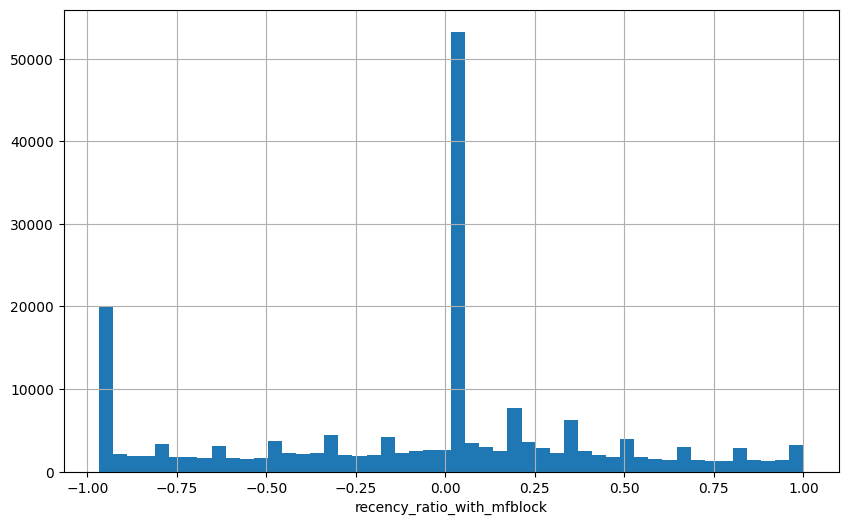

In [66]:
####### Feature 61: Block money flow includes only those trades greater than 10,000 or more shares.
featname = "recency_ratio_with_mfblock"
mfblock = data["load_simvar_hhmm"]("mfblock")
alpha = 1 - ts_days_since_max(mfblock, 63) / 63


alpha = op.at_nan2zero(alpha)

alpha = op.at_zero2nan(alpha) - 0.5
alpha = alpha*2

# alpha = normalize_features(alpha)


df[featname] = alpha[flatten_mask]

hist_show(df, featname)


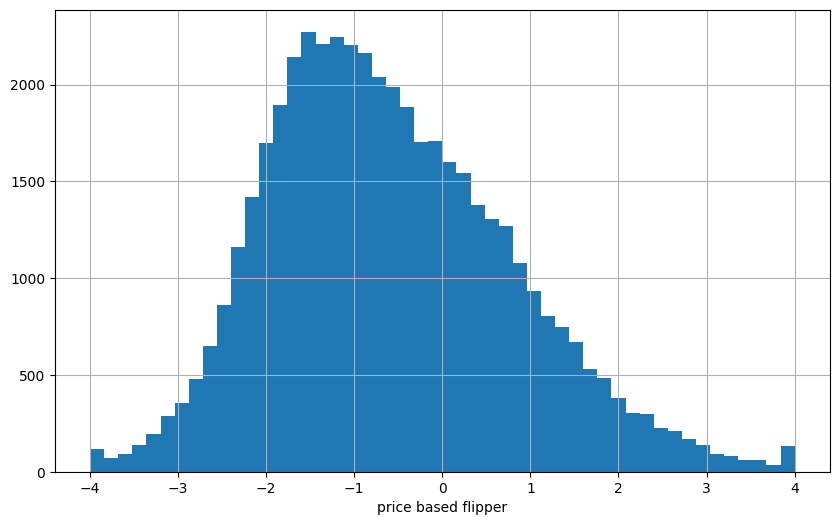

In [67]:
####### Feature 62: option based flipper
featname = 'price based flipper'
call_OTM = data['load_simvar_hhmm']('ivy_OTM_call_30_volsurf_premium_mean')
put_OTM = data['load_simvar_hhmm']('ivy_OTM_put_30_volsurf_premium_mean')
tsz_call_OTM = op.at_nan2zero(op.ts_zscore(call_OTM,20))
tsz_put_OTM = op.at_nan2zero(op.ts_zscore(put_OTM,20))
call_open_wt_data1 = data['load_simvar_hhmm']('ivy_OTM_put_60_best_bid_vol_wt_mean')
call_open_wt_data2 = data['load_simvar_hhmm']('ivy_OTM_put_60_best_offer_vol_wt_mean')
a = (call_open_wt_data2-call_open_wt_data1) / call_open_wt_data1
call_open_wt_data3 = data['load_simvar_hhmm']('ivy_OTM_call_60_best_bid_vol_wt_mean') 
call_open_wt_data4 = data['load_simvar_hhmm']('ivy_OTM_call_60_best_offer_vol_wt_mean') 
b = call_open_wt_data4-call_open_wt_data3 / call_open_wt_data3
alpha = np.where(tsz_put_OTM>tsz_call_OTM, op.ts_zscore(np.log(a),20), -op.ts_zscore(np.log(b),20))

alpha = op.at_zero2nan(alpha) - 0.5

alpha = normalize_features(alpha)

df[featname]= (alpha)[flatten_mask]

hist_show(df, featname)


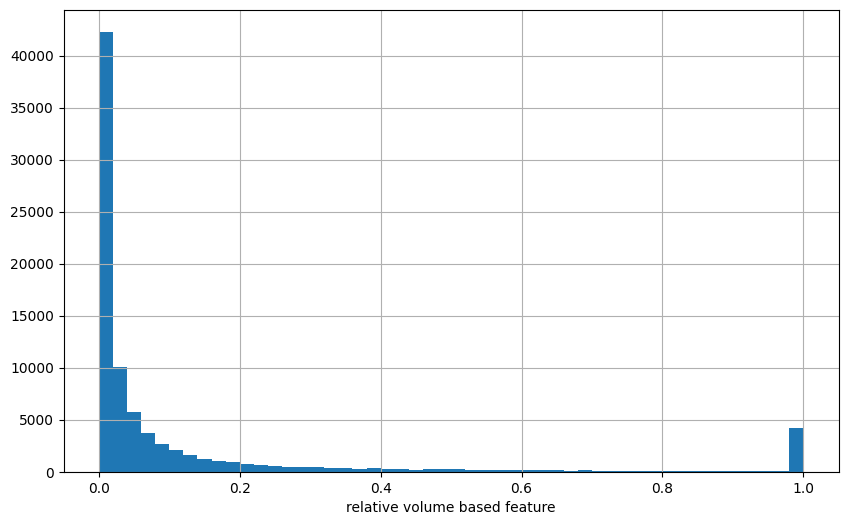

In [68]:
####### Feature 63: option volume
featname = 'relative volume based feature'
put_vol_data = data['load_simvar_hhmm']('ivy_OTM_put_30_volume_open_int_wt_mean') 
call_vol_data = data['load_simvar_hhmm']('ivy_OTM_call_30_volume_open_int_wt_mean') 
put_vol = op.at_nan2zero(put_vol_data)
call_vol = op.at_nan2zero(call_vol_data)
alpha = op.at_nan2zero((call_vol-put_vol)/put_vol)
alpha = op.at_zero2nan(alpha)
alpha = op.cs_winsor(alpha,0.05,False)

alpha = normalize_features(alpha)
alpha = (alpha+4)/8

df[featname]= (alpha)[flatten_mask]

hist_show(df, featname)


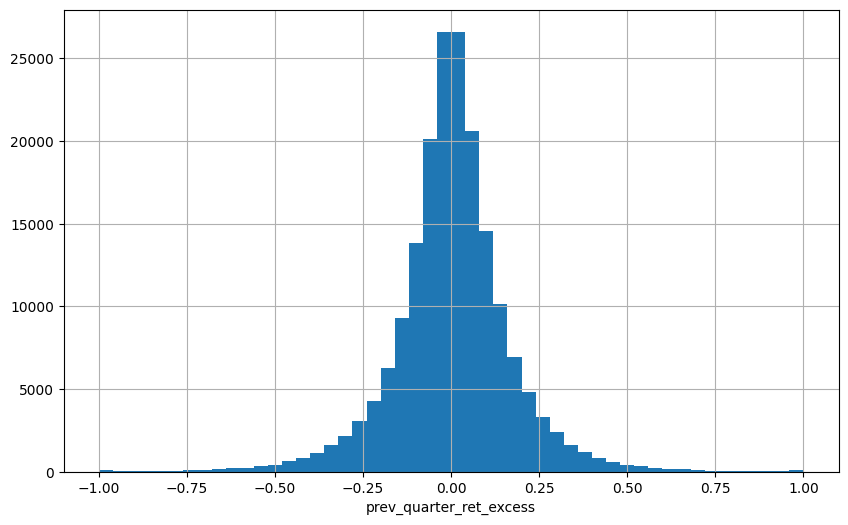

In [69]:
####### Feature 64: previous quarter ret5_excess
ret5_excess = data['load_simvar_hhmm']('ret5_excess')
ret5_excess = ret5_excess * op.ts_delay(1.0*flatten_mask,1)
ret5_excess = op.ts_fill(op.at_zero2nan(ret5_excess))
ret5_excess[ret5_excess>0.5] = 0.5
ret5_excess[ret5_excess<-0.5] = -0.5
ret5_excess = ret5_excess*2

# ret5_excess = normalize_features(ret5_excess)


df['prev_quarter_ret_excess'] = (ret5_excess)[flatten_mask]

hist_show(df, 'prev_quarter_ret_excess')


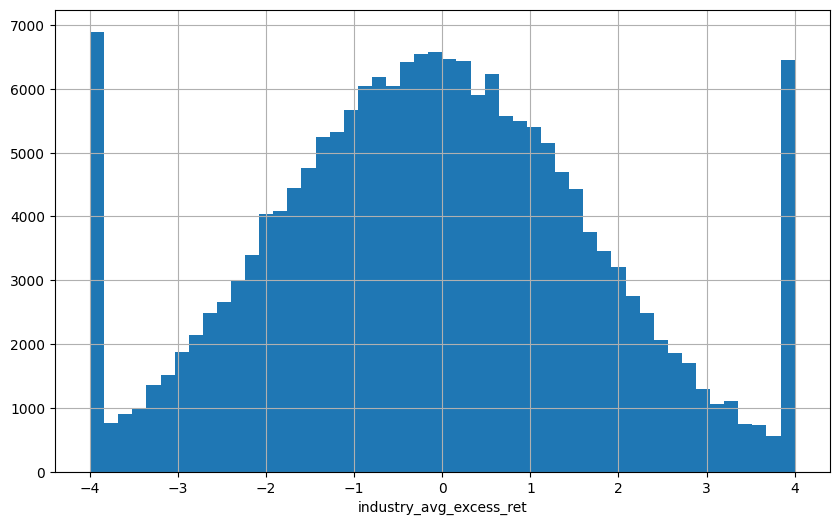

In [70]:
####### Feature 65: industry_avg_excess_ret
industry = data['load_simvar_hhmm']('industry')
industry_avg_excess_ret = np.full_like(ret5_excess, np.nan)
lookback_period = 20
# Iterate over the relevant stocks and days
for stock_idx,day_idx in zip(*np.where(flatten_mask)):
    # Industry of the current data point
    stock_industry = industry[stock_idx, day_idx]
    start_idx = max(0, day_idx - lookback_period)
    # Find stocks in the same industry that announced 
    # earnings within the lookback period
    industry_mask = (industry[:, start_idx:day_idx] == stock_industry) \
                    & flatten_mask[:, start_idx:day_idx]
    # Push the mask by 1 since we want the return on the day after betting
    industry_mask_next = (op.ts_delay(industry_mask*1.0,1) == 1.0)
    industry_returns = (ret5_excess[:, start_idx:day_idx])[industry_mask_next]
    if len(industry_returns) > 0:
        industry_avg_excess_ret[stock_idx, day_idx] = np.nanmean(industry_returns)
industry_avg_excess_ret = op.at_nan2zero(industry_avg_excess_ret)
# Add the new feature to the DataFrame

industry_avg_excess_ret = op.at_zero2nan(industry_avg_excess_ret)
industry_avg_excess_ret = normalize_features(industry_avg_excess_ret)

df['industry_avg_excess_ret'] = industry_avg_excess_ret[flatten_mask]

hist_show(df, 'industry_avg_excess_ret')


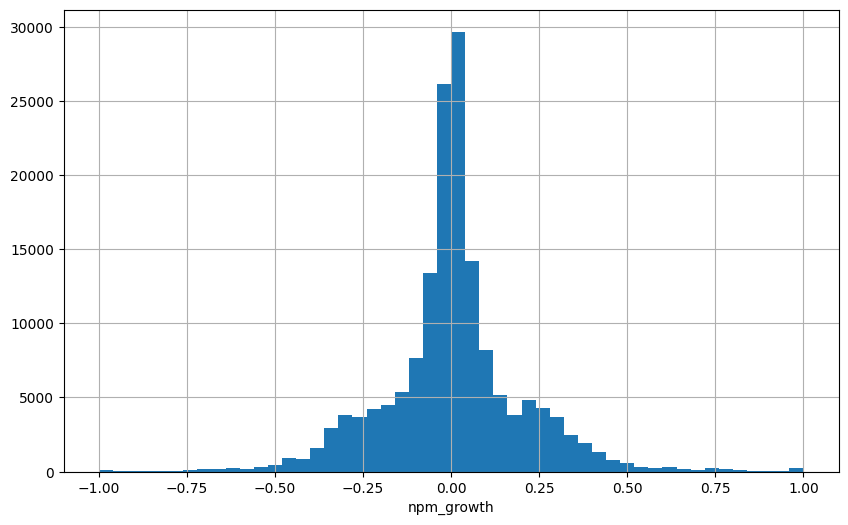

In [71]:
####### Feature 66: fundamental
# Net profit margin growth
bbg_ni = op.ts_fill(data['load_simvar_hhmm']('bbg_NET_INCOME'))
bbg_sales = op.ts_fill(data['load_simvar_hhmm']('bbg_SALES_REV_TURN'))

#Transformation which gets the change over a 1 year trailing period and winsorizes the output to limit extreme outlier betting
def trans(var):
    var = var-op.ts_delay(var,252)
    var = op.cs_winsor(var,0.1,False)
    return var
bbg_npm = (bbg_ni)/op.at_zero2nan(bbg_sales)
bbg_npm_chg_w = trans(bbg_npm)
bbg_npm_chg_w[bbg_npm_chg_w>0.5] = 0.5
bbg_npm_chg_w[bbg_npm_chg_w<-0.5] = -0.5
bbg_npm_chg_w = bbg_npm_chg_w*2

# bbg_npm_chg_w = normalize_features(bbg_npm_chg_w)

df['npm_growth'] = (bbg_npm_chg_w)[flatten_mask]

hist_show(df, 'npm_growth')


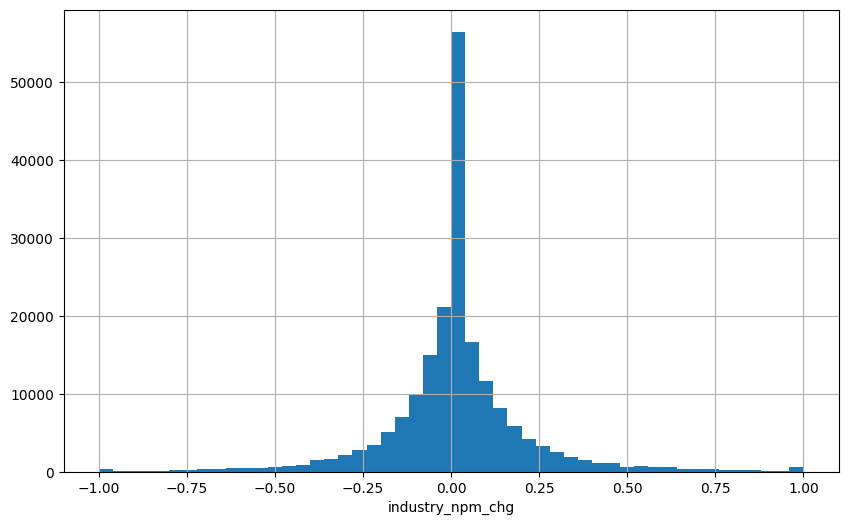

In [72]:
####### Feature 67: industry average of fundamental
# Industry average of feature over the lookback
industry = data['load_simvar_hhmm']('industry')
industry_npm_chg = np.full_like(bbg_npm, np.nan)
lookback_period = 5 
for stock_idx,day_idx in zip(*np.where(flatten_mask)):
    stock_industry = industry[stock_idx, day_idx]
    start_idx = max(0, day_idx - lookback_period-2)
    industry_mask = (industry[:, start_idx:day_idx-2] == stock_industry)\
                    & flatten_mask[:, start_idx:day_idx-2]
    industry_mask_next = (op.ts_delay(industry_mask*1.0,1) == 1.0)
    industry_npm_all = (bbg_npm_chg_w[:, start_idx:day_idx-2])[industry_mask_next]
    if len(industry_npm_all) > 0:
        industry_npm_chg[stock_idx, day_idx] = np.nanmean(industry_npm_all)
industry_npm_chg = op.at_nan2zero(industry_npm_chg)

# industry_npm_chg = normalize_features(industry_npm_chg)
industry_npm_chg[industry_npm_chg>0.5] = 0.5
industry_npm_chg[industry_npm_chg<-0.5] = -0.5
industry_npm_chg = industry_npm_chg*2

df['industry_npm_chg'] = industry_npm_chg[flatten_mask]

hist_show(df, 'industry_npm_chg')


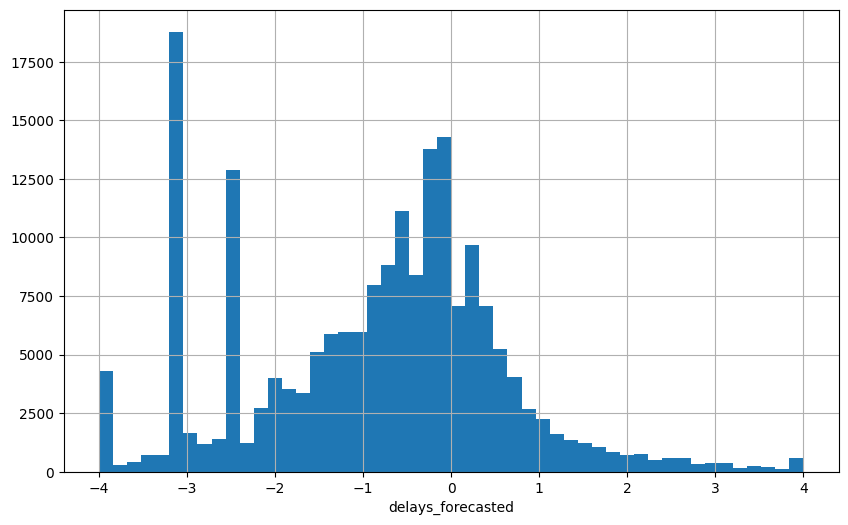

In [73]:
####### Feature 68: advancement/delay based on forecasts vs actual earnings announcement dates.
trading_days_since_last_ann = data['load_simvar_hhmm']('trading_days_since_last_ann')
EP = data['load_simvar_hhmm']('trading_days_til_next_ann') + trading_days_since_last_ann; #the earning period = days between 2 announcements.
mean_earning_period = op.ts_mean(op.ts_delay(EP, 10), 25); #the mean earning period forecast in the past month upto 2 weeks before the earnings announcement.
actual_diff = op.ts_delay(trading_days_since_last_ann, 1) + 1; #thea ctual difference between the last announcement and the current announcement. calculated when the ann is scheduled next day.
diff = (mean_earning_period - actual_diff); #difference from forecast and actual value.
mask_2 = (abs(diff) < 10);  #filtering out large diff values
mask_3 = (actual_diff < 95) * (actual_diff > 30); #filtering out announcements that happened too early or too late after the previous one.
signal = diff * mask_2 * mask_3;
signal = op.at_nan2zero(signal);


signal = normalize_features(signal)


updated_delays = op.at_nan2zero(signal[flatten_mask]);
df['delays_forecasted'] = updated_delays

hist_show(df, 'delays_forecasted')


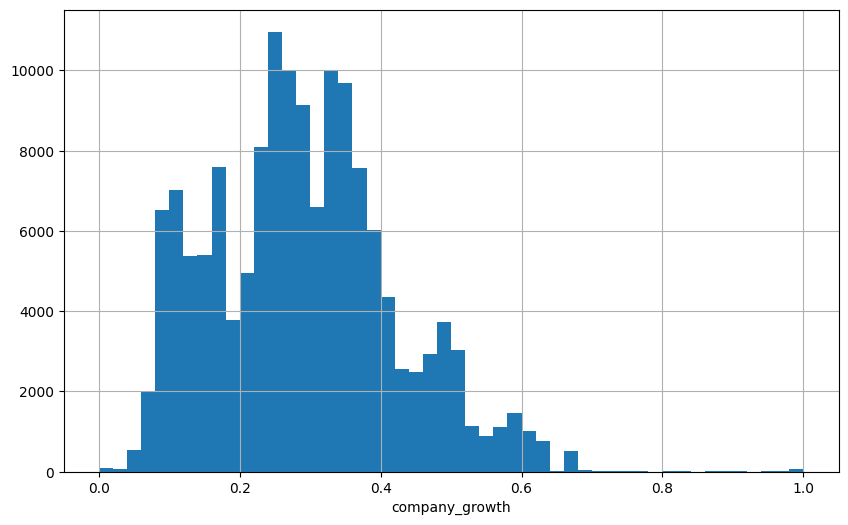

In [74]:
####### Feature 69: Company growth
def TTM_value(var, moy, fiscal_yr):
    quarter_now = np.zeros_like(var)
    quarter_now[moy>=fiscal_yr] = (moy-fiscal_yr)[moy>=fiscal_yr]
    quarter_now[moy<fiscal_yr] =(12 + moy - fiscal_yr)[moy<fiscal_yr]    
    quarter_now = (quarter_now // 4) + 1
    quarter1 = (quarter_now == 1)
    quarter2 = (quarter_now == 2)
    quarter3 = (quarter_now == 3)
    quarter4 = (quarter_now == 4)
    quarter1_val = op.at_nan2zero(op.ts_fill(op.at_zero2nan(quarter1 * var)))
    quarter2_val = op.at_nan2zero(op.ts_fill(op.at_zero2nan(quarter2 * var)))
    quarter3_val = op.at_nan2zero(op.ts_fill(op.at_zero2nan(quarter3 * var)))
    quarter4_val = op.at_nan2zero(op.ts_fill(op.at_zero2nan(quarter4 * var)))
    TTM_var = quarter1_val + quarter2_val + quarter3_val + quarter4_val
    return TTM_var

e_d = data['load_simvar_hhmm']('fast_REINVEST_EARN')
tot_eq = data['load_simvar_hhmm']('fast_BS_TOT_EQY')
moy = data['load_simvar_hhmm']('month_of_the_year')
fiscal_yr = data['load_simvar_hhmm']('cs_fiscal_year_end_month')
tot_eq_delayed = op.ts_delay(tot_eq, 252)
denom = 0.5 * (tot_eq + tot_eq_delayed)
growth = TTM_value(e_d, moy, fiscal_yr)/denom
growth = op.cs_zscore(growth)
growth = op.ts_delay(growth, 1)
growth = op.at_nan2zero(growth)

growth = op.at_zero2nan(growth)
growth = normalize_features(growth)
growth = (growth + 4)/8

df['company_growth'] = growth[flatten_mask]

hist_show(df, 'company_growth')


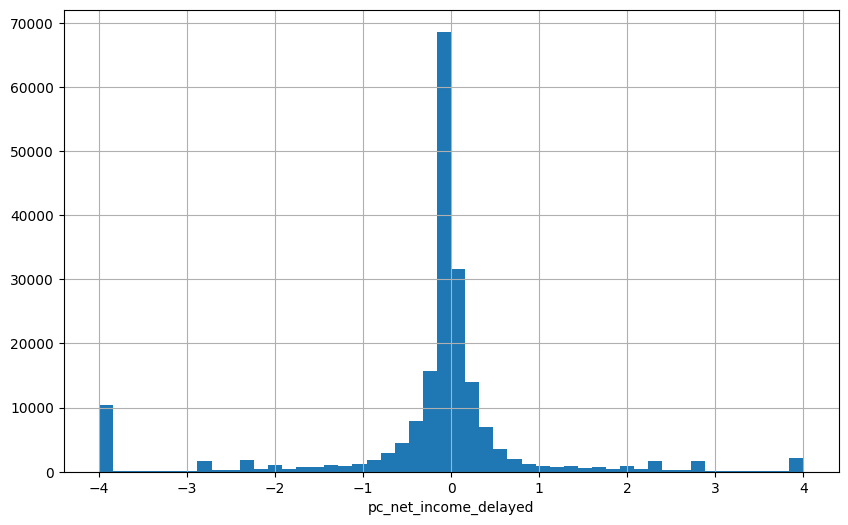

In [75]:
####### Feature 70: Income growth
income = op.ts_fill(data['load_simvar_hhmm']('rfi_NINC'))
income_delayed = op.ts_delay(income, 1)
income_delayed_last_yr = (op.ts_delay(income_delayed, 252))
growth_ = ((income_delayed - income_delayed_last_yr) / np.abs(income_delayed_last_yr)) *100
growth_z = op.ts_zscore(growth_, 63)
growth_z = op.at_nan2zero(growth_z) 

growth_z = normalize_features(growth_z)

df['pc_net_income_delayed']  = growth_z[flatten_mask]
hist_show(df, 'pc_net_income_delayed')


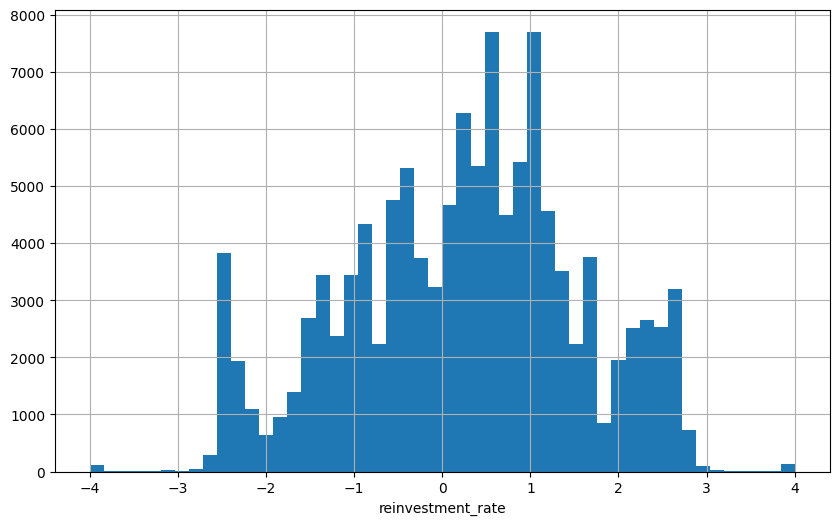

In [76]:
####### Feature 71: REINVESTMENT RATE
capex = data['load_simvar_hhmm']('bbg_CF_CAP_EXPEND_PRPTY_ADD')
depreciation = data['load_simvar_hhmm']('bbg_CF_DEPR_AMORT')
assets = data['load_simvar_hhmm']('bbg_ARD_TOTAL_CUR_ASSETS')
liabilities = data['load_simvar_hhmm']('bbg_BS_CUR_LIAB')
ebit = data['load_simvar_hhmm']('bbg_EBIT')
tax_rate = data['load_simvar_hhmm']('bbg_EFF_TAX_RATE')

# cap tax_rate to rid of outliers 
tax_rate = np.where(tax_rate>100, np.nan, tax_rate)
tax_rate = tax_rate / 100.0

delta_capex = abs(capex) - depreciation
ac_assets = assets - liabilities
delta_ac_assets = ac_assets - op.ts_delay(ac_assets, 252)

rein = op.ts_mean(op.ts_delay((delta_ac_assets + delta_capex) / (ebit*(1-tax_rate)), 1), 252)
rein = op.at_zero2nan(rein)
rein = normalize_features(rein)

df["reinvestment_rate"] = (rein)[flatten_mask]

hist_show(df, 'reinvestment_rate')


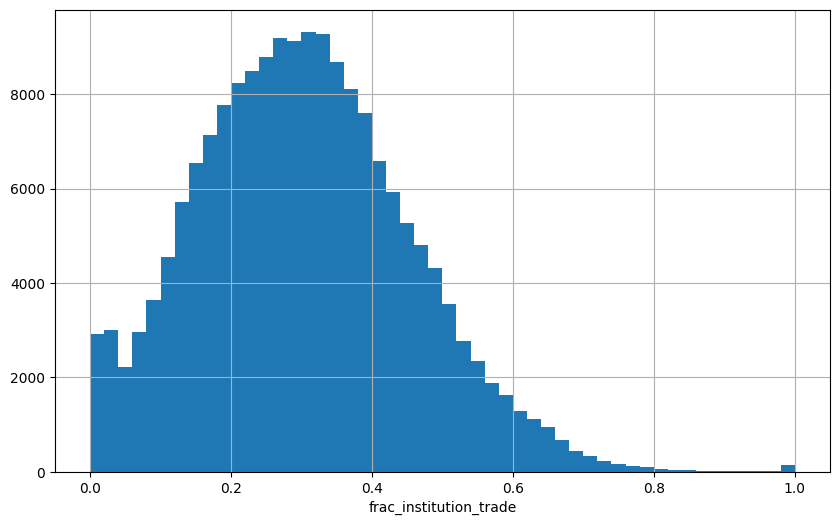

In [77]:
####### feature 72: fraction of trade volume
volume_ins = data['load_simvar_hhmm']('institutiontrade_volume_allday') 
volume = data['load_simvar_hhmm']('volume')
frac_institution_trade = op.at_nan2zero(volume_ins/volume)
frac_institution_trade = op.at_zero2nan(frac_institution_trade)
frac_institution_trade = normalize_features(frac_institution_trade)

frac_institution_trade = (frac_institution_trade+4)/8

df['frac_institution_trade'] = frac_institution_trade[flatten_mask]

hist_show(df, 'frac_institution_trade')


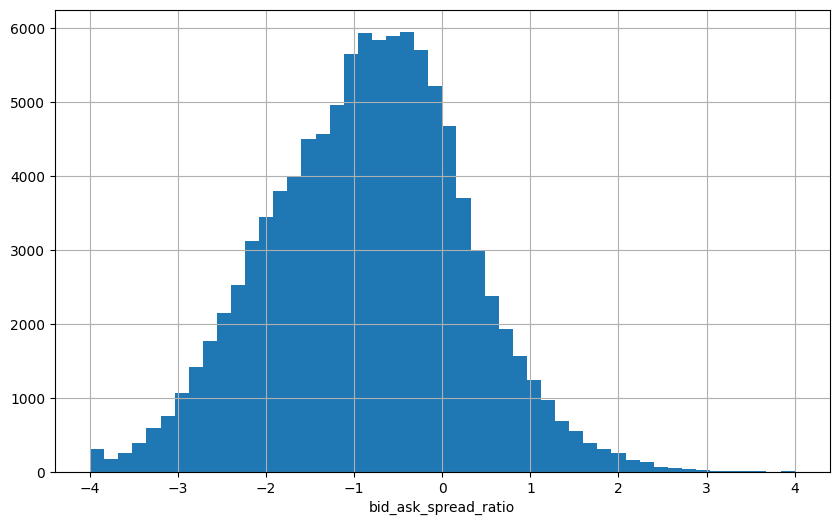

In [78]:
####### feature 73: BID_ASK_SPREAD_RATIO (Natural Log transform on (ask_price - bid_price)/last_price)
bas = data['load_simvar_hhmm']('bbg_BID_ASK_SPREAD_RATIO')
bas = np.log(bas)
bas = op.ts_fill(op.at_zero2nan(bas))
bas = op.at_nan2zero(bas)
bas = op.at_zero2nan(bas)

bas = normalize_features(bas)

df['bid_ask_spread_ratio'] = bas[flatten_mask]
hist_show(df, 'bid_ask_spread_ratio')


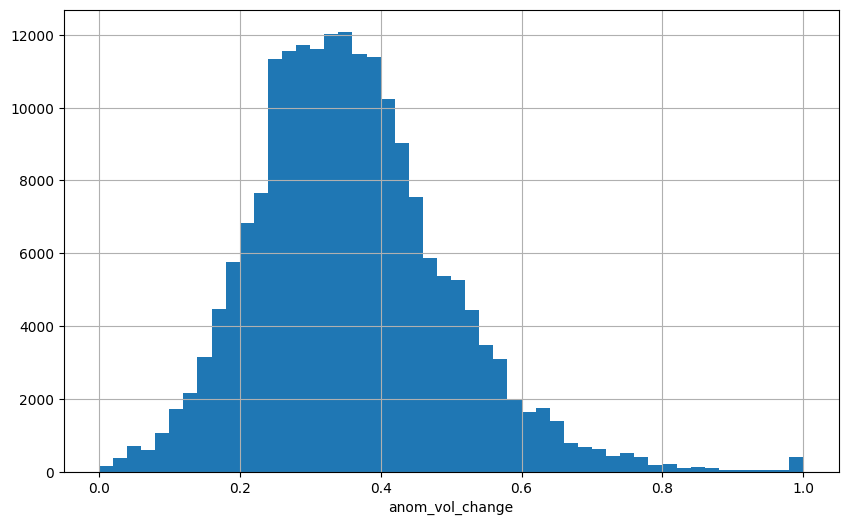

In [79]:
####### feature 74: anomalous volume
uvolume = data['load_simvar_hhmm']('uvolume')
uvolume_63 = op.ts_mean(uvolume, 63)
uvolume_anomaly =  op.at_nan2zero(uvolume - uvolume_63)
uvolume_anomaly = op.at_zero2nan(uvolume_anomaly)
uvolume_anomaly = normalize_features(uvolume_anomaly)

uvolume_anomaly = (uvolume_anomaly + 4)/8

df['anom_vol_change'] = uvolume_anomaly[flatten_mask]

hist_show(df, 'anom_vol_change')


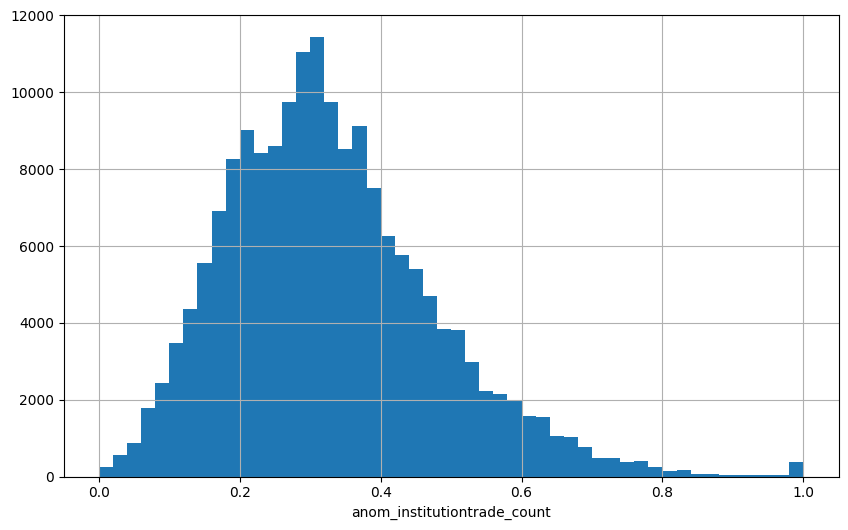

In [80]:
####### feature 75: institution trade count
insti_trade_count = data['load_simvar_hhmm']('institutiontrade_count_allday')
insti_trade_count_63 = op.ts_mean(insti_trade_count, 63)
insti_trade_count_anomaly =  op.at_nan2zero(insti_trade_count - insti_trade_count_63)
insti_trade_count_anomaly = op.at_zero2nan(insti_trade_count_anomaly)

insti_trade_count_anomaly = normalize_features(insti_trade_count_anomaly)

insti_trade_count_anomaly = (insti_trade_count_anomaly+4)/8

df['anom_institutiontrade_count'] = insti_trade_count_anomaly[flatten_mask]

hist_show(df, 'anom_institutiontrade_count')


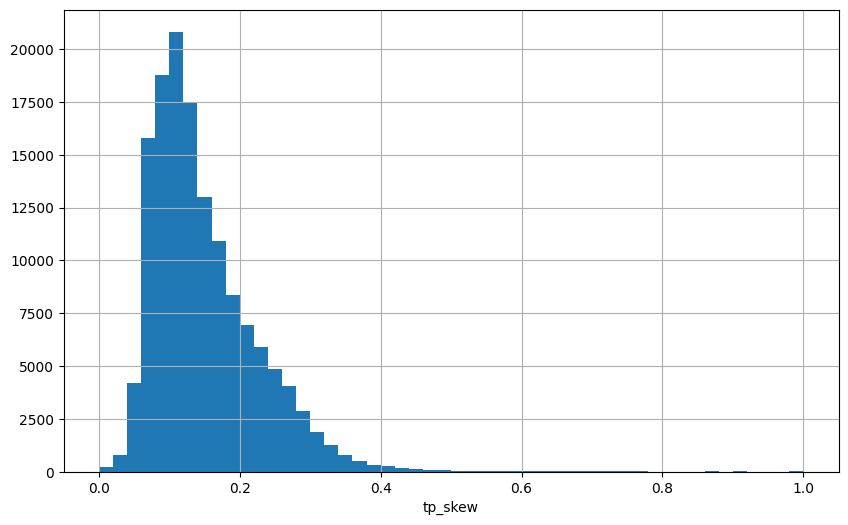

In [81]:
####### feature 76: target price skewness
# target price estimates 
tp_mean = op.ts_fill(data['load_simvar_hhmm']('zacks_ce_tp_mean'))
tp_median = op.ts_fill(data['load_simvar_hhmm']('zacks_ce_tp_median'))
tp_skew = (tp_mean - tp_median) / np.abs(tp_median)
tp_skew = op.at_zero2nan(tp_skew)
tp_skew = normalize_features(tp_skew)

tp_skew = (tp_skew+4)/8

df['tp_skew'] = (tp_skew)[flatten_mask]

hist_show(df, 'tp_skew')


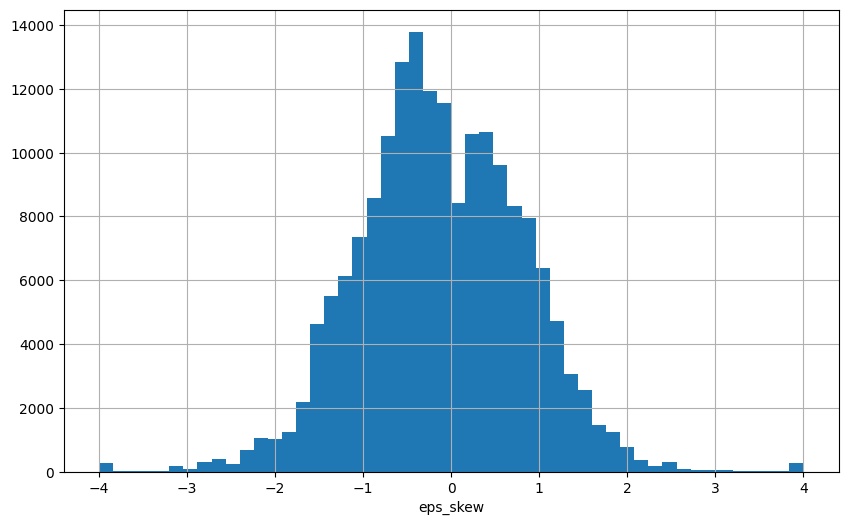

In [82]:
####### feature 77: EPS skewness
# # earnings per share estimates 
eps_mean = op.ts_fill(data['load_simvar_hhmm']('zacks_ce_eps_mean_next_q1'))
eps_median = op.ts_fill(data['load_simvar_hhmm']('zacks_ce_eps_median_next_q1'))
eps_skew = (eps_mean - eps_median) / np.abs(eps_median)

eps_skew = normalize_features(eps_skew)

df['eps_skew'] = (eps_skew)[flatten_mask]

hist_show(df, 'eps_skew')


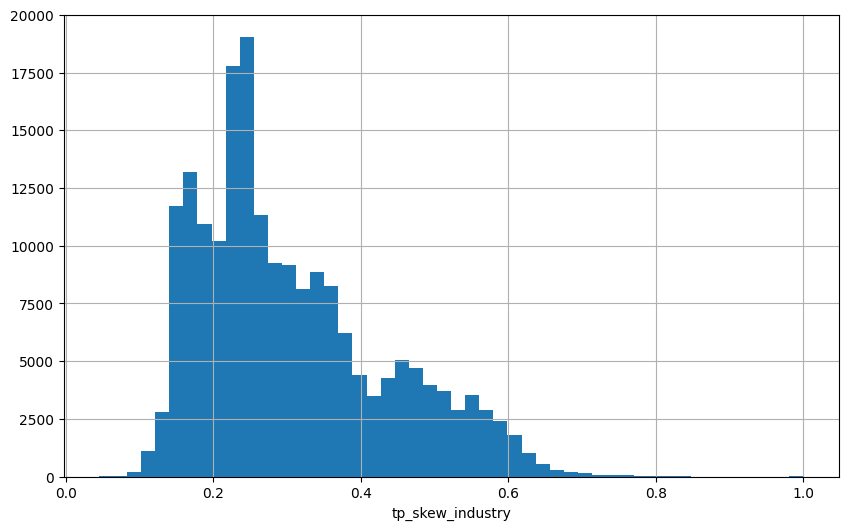

In [83]:
####### feature 78: industry spillover
def grp_avg(input, group):
    out = np.full_like(input, np.nan)
    for day in range(input.shape[1]):
        for grp in np.unique(group[:, day]):
            idx = group[:, day] == grp
            out[idx, day] = np.nanmean(input[idx, day])
    return out

grp = data['load_simvar_hhmm']('industry')

feat = op.at_nan2zero(grp_avg(tp_skew, grp))
feat = op.at_zero2nan(feat)

feat[feat<0] = 0
feat[feat>0.5] = 0.5
feat = feat*2

# feat = (feat+4)/8

# feat = normalize_features(feat)

df['tp_skew_industry'] = feat[flatten_mask]

hist_show(df, 'tp_skew_industry')


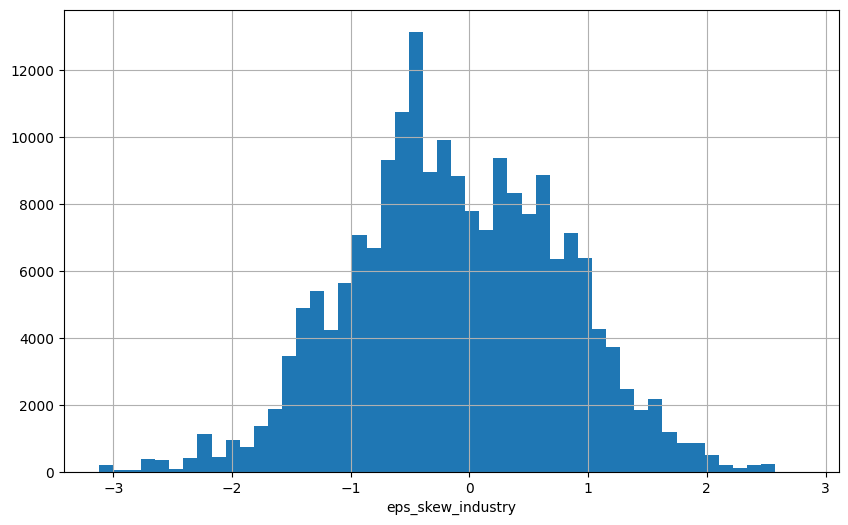

In [84]:
####### feature 79: Industry average EPS skewness

feat = op.at_nan2zero(grp_avg(eps_skew, grp))
feat = op.at_zero2nan(feat)
# feat = normalize_features(feat)

df['eps_skew_industry'] = feat[flatten_mask]

hist_show(df, 'eps_skew_industry')


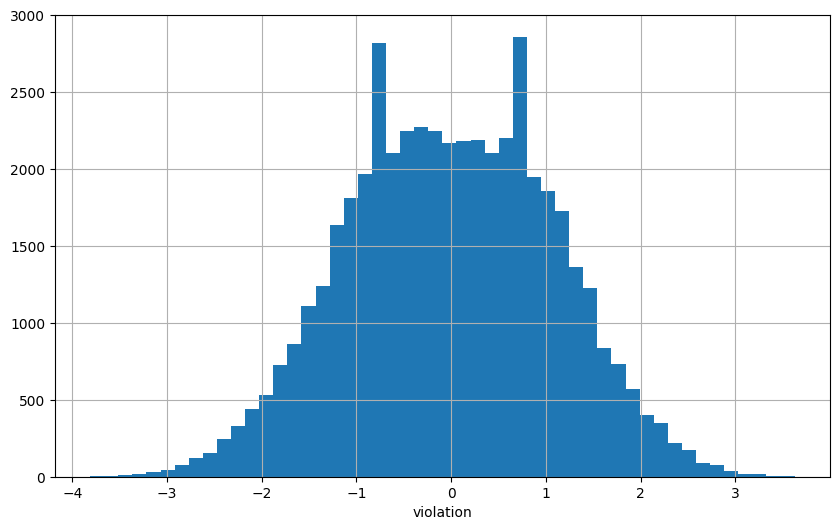

In [85]:
####### feature 80: Put Call Parity Violations
put_bid=data['load_simvar_hhmm']('nanex_ATM_put_60_best_bid_vol_wt_mean')
put_ask=data['load_simvar_hhmm']('nanex_ATM_put_60_best_offer_vol_wt_mean')
call_bid=data['load_simvar_hhmm']('nanex_ATM_call_60_best_bid_vol_wt_mean')
call_ask=data['load_simvar_hhmm']('nanex_ATM_call_60_best_offer_vol_wt_mean')

upper_bound=call_ask-put_bid
lower_bound=call_bid-put_ask

violation = upper_bound * (upper_bound < 0) + lower_bound* (lower_bound > 0)
violation = op.at_nan2zero(op.ts_zscore(op.ts_mean(violation,5),21))

violation = op.at_zero2nan(violation)
# violation = normalize_features(violation)

df["violation"] = violation[flatten_mask] 

hist_show(df, 'violation')


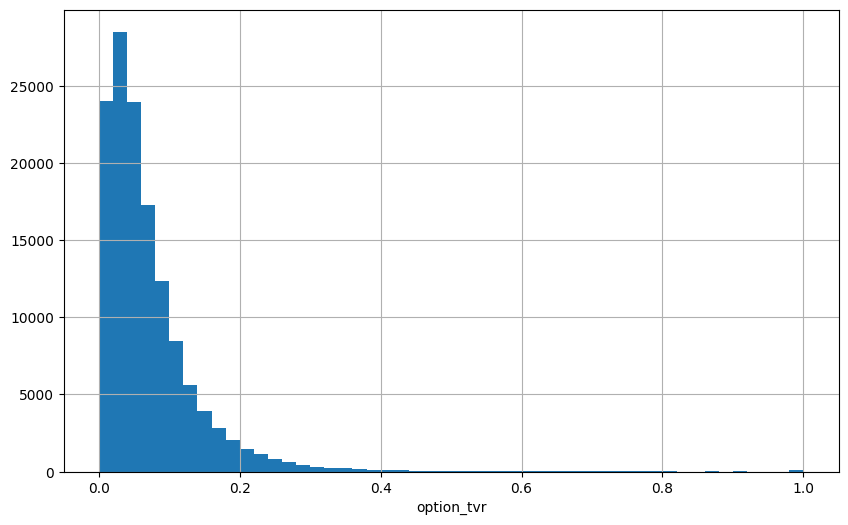

In [86]:
####### feature 81: Options Turnover
option_volume=data['load_simvar_hhmm']('ivy_volume')
option_open_interest=data['load_simvar_hhmm']('ivy_open_interest')

option_tvr=op.at_nan2zero(op.ts_mean(option_volume,20)/option_open_interest)

option_tvr = op.at_zero2nan(option_tvr)
option_tvr = normalize_features(option_tvr)

option_tvr = (option_tvr+4)/8

df['option_tvr']=option_tvr[flatten_mask]

hist_show(df, 'option_tvr')


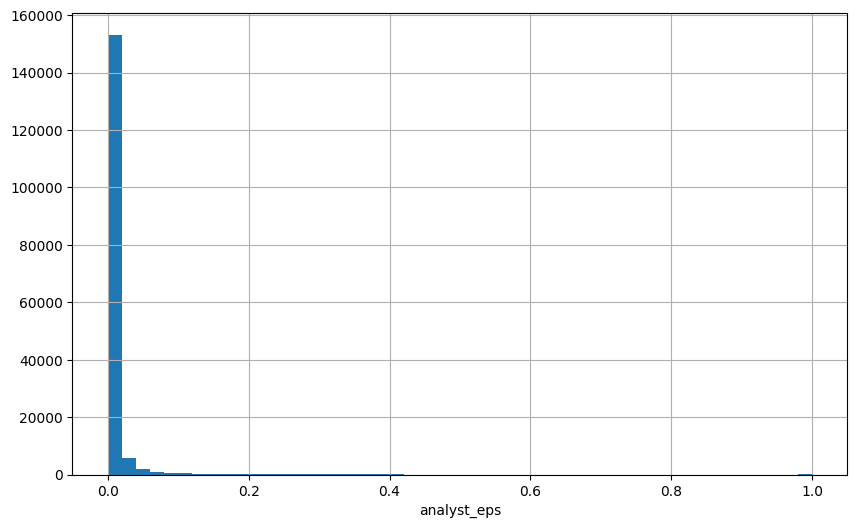

In [87]:
####### feature 82: Analyst eps forecast dispersion
analyst_std=op.ts_fill(data['load_simvar_hhmm']('zacks_ce_eps_stddev_next_q1'))
analyst_mean=op.ts_fill(data['load_simvar_hhmm']('zacks_ce_eps_mean_next_q1'))

analyst_eps=op.at_nan2zero(analyst_std/np.abs(analyst_mean))
analyst_eps = op.at_zero2nan(analyst_eps)
analyst_eps = normalize_features(analyst_eps)

analyst_eps = (analyst_eps + 4)/8

df['analyst_eps']=analyst_eps[flatten_mask]

hist_show(df, 'analyst_eps')


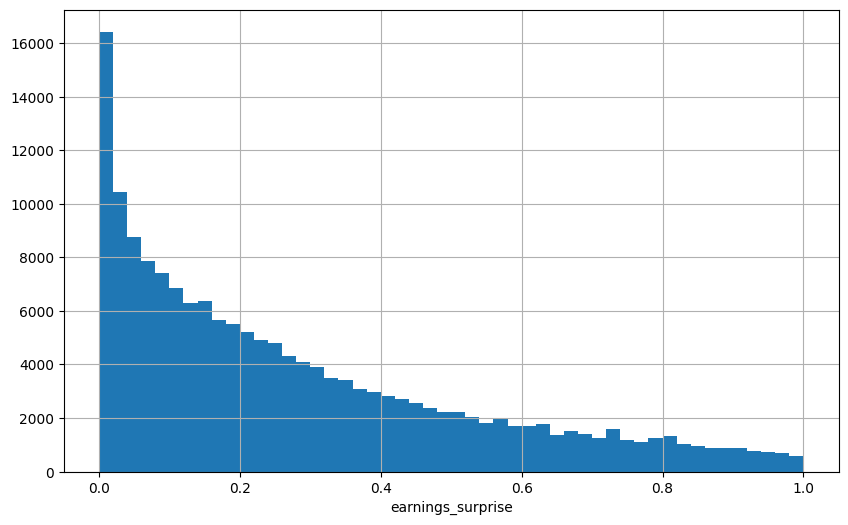

In [88]:
####### feature 83: markit_FC_FQSURStd_EMM * ts_delay_1 of markit_FC_FQSURStd_EMM
markit_FC_FQSURStd_EMM = data['load_simvar_hhmm']('markit_FC_FQSURStd_EMM')
earnings_surprise = op.at_nan2zero(markit_FC_FQSURStd_EMM * op.ts_delay(markit_FC_FQSURStd_EMM, 63))

earnings_surprise = op.at_zero2nan(earnings_surprise)
earnings_surprise = normalize_features(earnings_surprise)

earnings_surprise = (earnings_surprise+4)/8

df['earnings_surprise'] = earnings_surprise[flatten_mask]

hist_show(df, 'earnings_surprise')


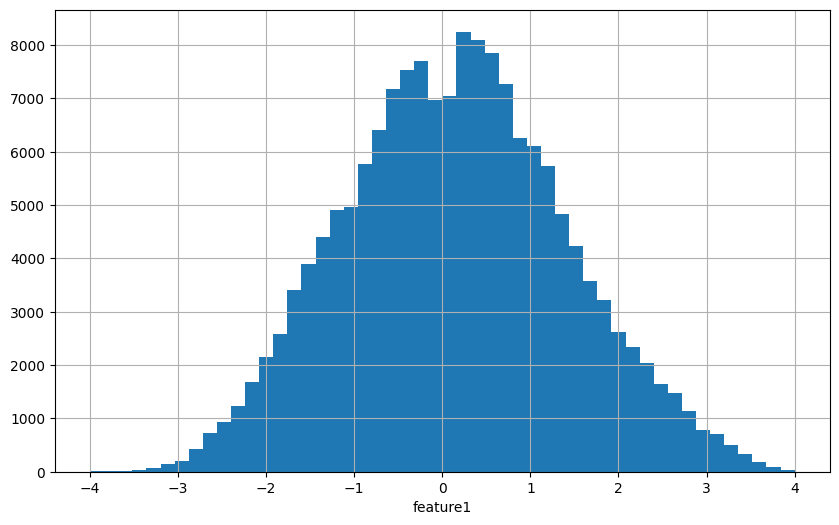

In [89]:
####### feature 84: EPS Growth
feature = op.at_nan2zero(op.ts_zscore(data['load_simvar_hhmm']('markit_FC_Q1AEpsG'),63))  
feature = op.cs_winsor(feature,0.02,False)

feature = op.at_zero2nan(feature)
# feature[feature>4] = 4
# feature[feature<-4] = -4

feature = np.clip(feature,-4,4)
# feature = normalize_features(feature)

df['feature1'] = (feature)[flatten_mask]

hist_show(df, 'feature1')


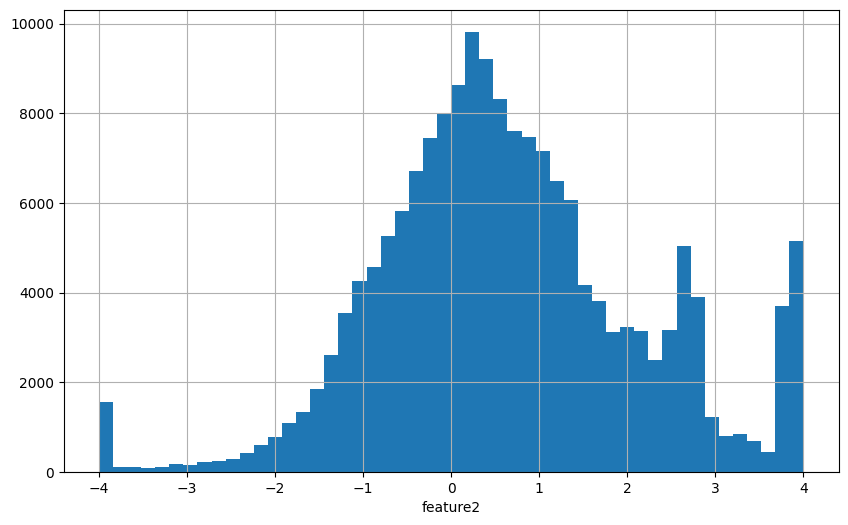

In [90]:
####### feature 85: Operating Income over mktcap
close = data['load_simvar_hhmm']('close')
shares = data['load_simvar_hhmm']('shsout')
feature2 = op.at_nan2zero(op.cs_zscore((data['load_simvar_hhmm']('rfi_SOPI')/(close*shares))))  
feature2 = op.cs_winsor(feature2,0.01)

feature2 = op.at_zero2nan(feature2)
feature2 = normalize_features(feature2)

df['feature2'] = (feature2)[flatten_mask]

hist_show(df, 'feature2')


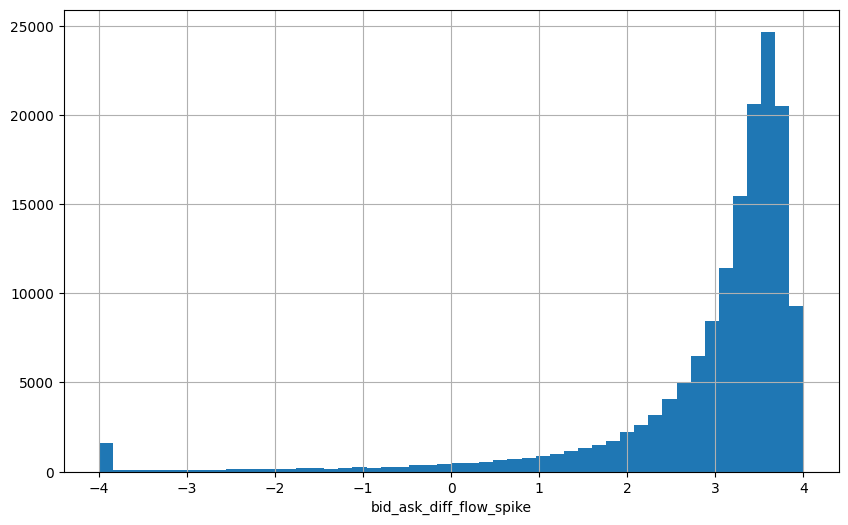

In [91]:
####### feature 86: weighted bid-ask spread
vol = data['load_simvar_hhmm']('volume')
vol_mean = op.ts_mean_exp(vol, 5, 0.2)
vol_activity_spike = vol / vol_mean

bid_afternoon = data['load_simvar_hhmm']('bid_afternoon')
ask_afternoon = data['load_simvar_hhmm']('ask_afternoon')
bid_ask_diff = (bid_afternoon - ask_afternoon) / (bid_afternoon + ask_afternoon)
skew = op.ts_skew(bid_ask_diff, 5)
bid_ask_diff_flow = bid_ask_diff * np.abs(skew)

bid_ask_diff_flow_spike = op.at_nan2zero(bid_ask_diff_flow) * vol_activity_spike

bid_ask_diff_flow_spike = op.at_zero2nan(bid_ask_diff_flow_spike)
bid_ask_diff_flow_spike = op.cs_winsor(bid_ask_diff_flow_spike,0.01)

bid_ask_diff_flow_spike = normalize_features(bid_ask_diff_flow_spike)

df['bid_ask_diff_flow_spike'] = (bid_ask_diff_flow_spike)[flatten_mask]

hist_show(df, 'bid_ask_diff_flow_spike')


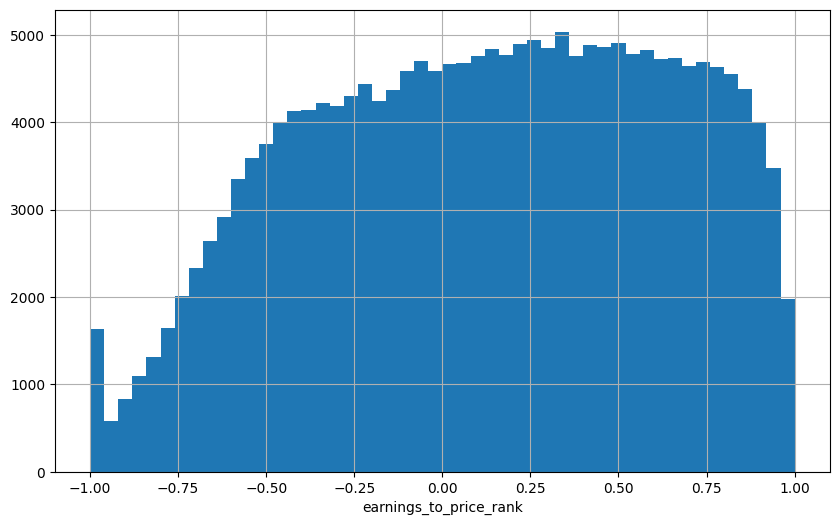

In [92]:
####### feature 87: fundamental ep ration
def final_feature():
    fast_IS_DILUTED_EPS = data['load_simvar_hhmm']('fast_IS_DILUTED_EPS')
    close = data['load_simvar_hhmm']('close')
    earnings_to_price_ratio = op.ts_fill(fast_IS_DILUTED_EPS) / op.ts_fill(close)
    delayed_earnings_to_price_ratio = op.ts_delay(earnings_to_price_ratio, 2)
    return np.nan_to_num(op.cs_rank(delayed_earnings_to_price_ratio), nan=1.0)

feat = final_feature()
feat = op.at_zero2nan(feat)-1.5

feat = feat*2
df['earnings_to_price_rank'] = feat[flatten_mask]

hist_show(df, 'earnings_to_price_rank')


In [93]:
print('87 features done')

87 features done


# Re-name all features to `f_1, ..., f_87`

In [96]:
########## final df #############
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.fillna(0) #here we fill the missing values with zeros, you may change this if required

valid_enddate = 20201231

df_train_valid = df.copy()
df_train_valid.columns = ['target', 'si', 'di', 'dates'] + [f'f_{i}' for i in range(1,88)]
df_train_valid[df_train_valid['dates']>valid_enddate] = 0


In [98]:
df_train_valid.head()

,target,si,di,dates,f_1,f_2,f_3,f_4,f_5,f_6,...,f_78,f_79,f_80,f_81,f_82,f_83,f_84,f_85,f_86,f_87
0,-0.077856,0,91,20060515,1.675064,-3.543791,0.0,0.117937,0.223391,0.204918,...,0.660344,-2.203576,0.0,0.026984,0.014756,0.296930,-0.143285,-2.209795,0.0,0.988768
1,0.060149,0,154,20060814,2.829584,-0.971235,0.0,0.167683,0.274383,0.080645,...,0.570215,-0.809808,0.0,0.163592,0.001462,0.192673,1.179825,-0.056549,0.0,-0.199212
2,0.000519,0,219,20061114,-4.000000,1.011942,0.0,0.148286,0.156317,0.403226,...,0.515856,0.207212,0.0,0.043833,0.001657,0.184418,-0.732389,-0.359123,0.0,0.372511
3,-0.033467,0,281,20070215,2.133138,-0.024707,0.0,0.124794,0.762421,-0.016129,...,0.491581,-0.398909,0.0,0.041851,0.002310,0.332033,-0.403183,-0.189155,0.0,0.024313
4,0.059087,0,341,20070514,-0.971314,0.013317,0.0,0.215762,0.124846,-0.274194,...,0.231417,1.502377,0.0,0.045468,0.003572,0.535954,0.505986,-0.004705,0.0,0.004356
